 SCRIPT 1 (1D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS 
[+] Calculando Matriz de Covarianza Teórica del Modelo Estándar...

[+] Generando 200 puntos teóricos con Flavio en el espacio...

[+] Entrenando los Procesos Gaussianos en 1D...

[+] Generando Set de Validación (200 puntos) para testear el GP 1D...


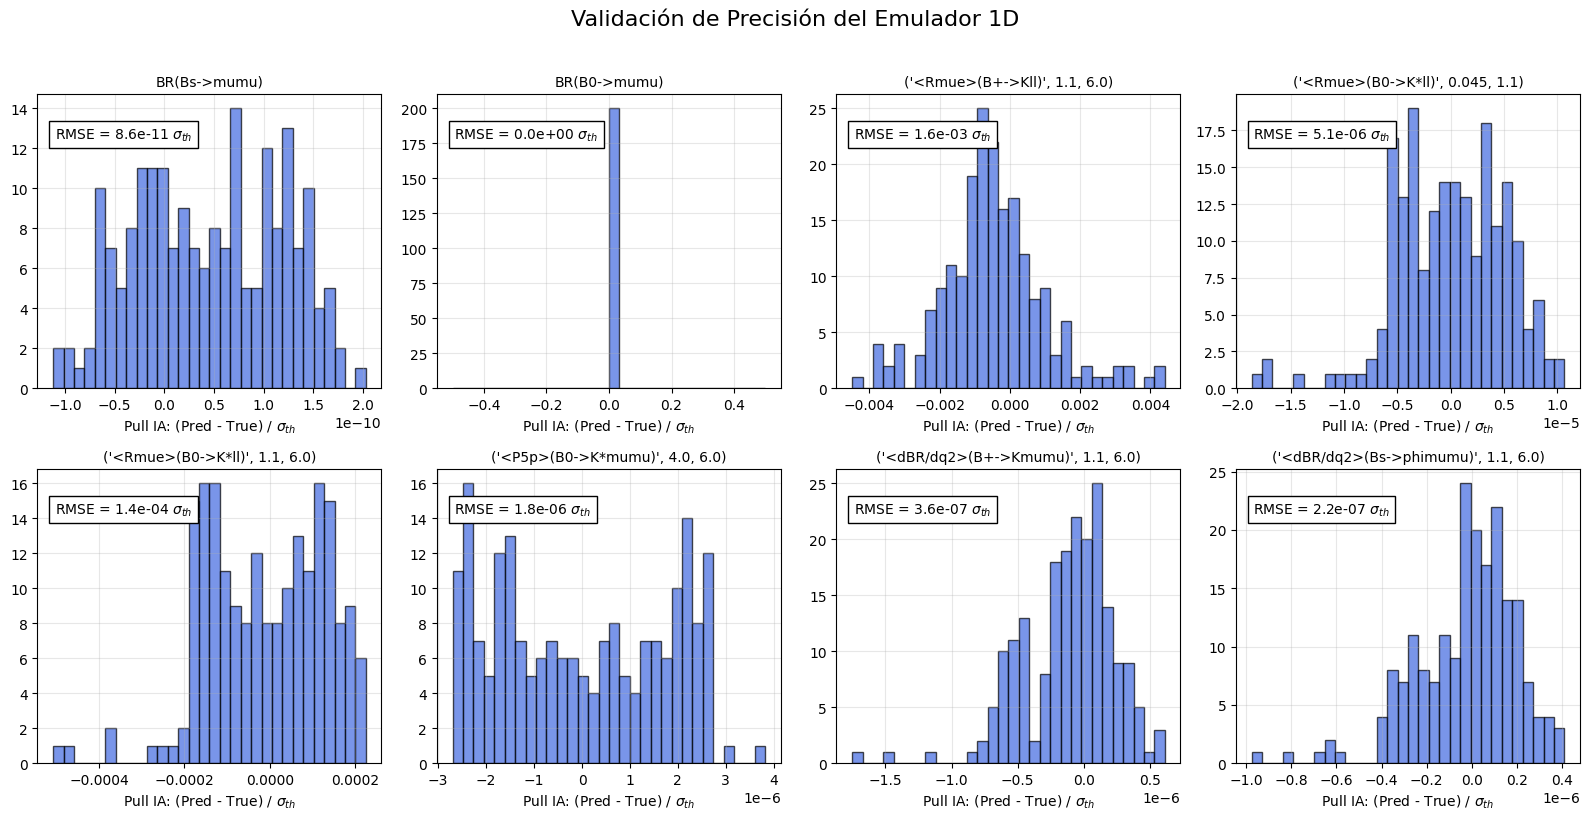


[+] Guardando modelo en disco...
 -> ¡ÉXITO! Modelo guardado como 'emulador_c9_1d.joblib'.


In [ ]:
import numpy as np
import pandas as pd
import warnings
import joblib
import matplotlib.pyplot as plt
from scipy.stats import qmc
import flavio
from wilson import Wilson
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 1 (1D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS ")
print("="*85)

i_seed = 42
np.random.seed(i_seed)

observables = [
    'BR(Bs->mumu)', 'BR(B0->mumu)',  
    ('<Rmue>(B+->Kll)', 1.1, 6.0), ('<Rmue>(B0->K*ll)', 0.045, 1.1),      
    ('<Rmue>(B0->K*ll)', 1.1, 6.0), ('<P5p>(B0->K*mumu)', 4.0, 6.0),
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0), ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

# =====================================================================
# 1. COVARIANZA TEÓRICA
# =====================================================================
print(" Calculando Matriz de Covarianza Teórica del Modelo Estándar...")
cov_matrix_th_raw = flavio.sm_covariance(observables, N=2000, threads=1)
cov_matrix_th = cov_matrix_th_raw.loc[observables, observables].values if isinstance(cov_matrix_th_raw, pd.DataFrame) else cov_matrix_th_raw

# =====================================================================
# 2. ESPACIO DE ENTRENAMIENTO GLOBAL (1D)
# =====================================================================
bounds_low = [-3.0]
bounds_high = [1.0]
N_train = 200
MAX_GP_POINTS = 7000

print(f"\n Generando {N_train} puntos teóricos con Flavio en el espacio...")
print(f"    C9:  [{bounds_low[0]}, {bounds_high[0]}]")
sampler = qmc.LatinHypercube(d=1, seed=i_seed)
X_raw = qmc.scale(sampler.random(n=N_train), bounds_low, bounds_high)

# [ÚNICA MEJORA APLICADA]: Prevención de colapso de RAM para N > 2000
if N_train > MAX_GP_POINTS:
    print(f" Reduciendo a {MAX_GP_POINTS} Inducing Points representativos con KMeans para acelerar el GP...")
    kmeans = KMeans(n_clusters=MAX_GP_POINTS, random_state=i_seed, n_init='auto').fit(X_raw)
    X_train = kmeans.cluster_centers_
else:
    X_train = X_raw

def get_flavio_preds(c9):
    wc = Wilson({'C9_bsmumu': c9}, scale=5.0, eft='WET', basis='flavio')
    return [flavio.np_prediction(obs[0], wc, obs[1], obs[2]) if isinstance(obs, tuple) else flavio.np_prediction(obs, wc) for obs in observables]

Obs_train = np.array([get_flavio_preds(x[0]) for x in X_train])

# =====================================================================
# 3. ENTRENAMIENTO DE LOS PROCESOS GAUSSIANOS (VUELTA A GPs INDEPENDIENTES)
# =====================================================================
print("\n Entrenando los Procesos Gaussianos en 1D...")
gps, scalers_y = {}, {}
scaler_x = StandardScaler().fit(X_train)
X_train_scaled = scaler_x.transform(X_train)

for i, col in enumerate(observables):
    col_name = str(col)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(Obs_train[:, i].reshape(-1, 1)).ravel()
    
    kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(1), length_scale_bounds=(1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=i_seed)
    gp.fit(X_train_scaled, y_scaled)
    
    gps[col_name] = gp
    scalers_y[col_name] = scaler_y

# =====================================================================
# 4. VALIDACIÓN DE PULLS (TEST SET INDEPENDIENTE)
# =====================================================================
N_val = 200
print(f"\n Generando Set de Validación ({N_val} puntos) para testear el GP 1D...")
X_val = qmc.scale(sampler.random(n=N_val), bounds_low, bounds_high)
Obs_val = np.array([get_flavio_preds(x[0]) for x in X_val])

X_val_scaled = scaler_x.transform(X_val)
preds_val = []
for i, col in enumerate(observables):
    col_name = str(col)
    m_scaled = gps[col_name].predict(X_val_scaled)
    m_real = scalers_y[col_name].inverse_transform(m_scaled.reshape(-1, 1)).ravel()
    preds_val.append(m_real)
preds_val = np.column_stack(preds_val)

err_th_static = np.sqrt(np.diag(cov_matrix_th))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(observables):
    ax = axes[i]
    residual_pull = (preds_val[:, i] - Obs_val[:, i]) / err_th_static[i]
    ax.hist(residual_pull, bins=30, color='royalblue', alpha=0.7, edgecolor='black')
    ax.set_title(str(col), fontsize=10)
    ax.set_xlabel(r"Pull IA: (Pred - True) / $\sigma_{th}$")
    ax.grid(alpha=0.3)
    rmse_pull = np.sqrt(np.mean(residual_pull**2))
    ax.text(0.05, 0.85, f"RMSE = {rmse_pull:.1e} $\sigma_{{th}}$", transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white'))

plt.suptitle("Validación de Precisión del Emulador 1D", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GUARDAR EL MODELO
# =====================================================================
print("\n Guardando modelo en disco...")
paquete_exportacion = {
    'observables': observables,
    'gps': gps,
    'scalers_y': scalers_y,
    'scaler_x': scaler_x,
    'bounds_low': bounds_low,
    'bounds_high': bounds_high,
    'cov_matrix_th': cov_matrix_th
}
joblib.dump(paquete_exportacion, 'emulador_c9_1d.joblib')
print(" -> ¡ÉXITO! Modelo guardado como 'emulador_c9_1d.joblib'.")
print("="*85)

<>:198: SyntaxWarning: invalid escape sequence '\D'
<>:199: SyntaxWarning: invalid escape sequence '\D'
<>:199: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
<>:198: SyntaxWarning: invalid escape sequence '\D'
<>:199: SyntaxWarning: invalid escape sequence '\D'
<>:199: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
<>:200: SyntaxWarning: invalid escape sequence '\D'
C:\Users\almol\AppData\Local\Temp\ipykernel_8436\315777882.py:198: SyntaxWarning: invalid escape sequence '\D'
  df_imp = pd.DataFrame(list(importancia_fisica.items()), columns=['Observable', 'Mejora $\Delta\chi^2$'])
C:\Users\almol\AppData\Local\Temp\ipykernel_8436\315777882.py:199: SyntaxWarning: invalid escape sequence '\D'
  df_imp['Mejora $\Delta\chi^2$'] = df_imp['Mejora $\Delta\chi^2$'].clip(lower=0)
C:\Users\almol\AppData\Local\Temp\ipykernel_8436\315777882.py:199: Sy

 SCRIPT 2 (1D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD 
 Emulador IA 1D cargado correctamente.

 Buscando el Mínimo Global en 1D...

 Perfilando errores asimétricos...

 Paso 5 omitido: No hay correlaciones cruzadas en un espacio 1D.

 Desglose de Incertidumbres en el Mínimo Global:
-------------------------------------------------------------------------------------
 OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) 
-------------------------------------------------------------------------------------
 BR(Bs->mumu)                   |       11.68 |            2.75 |           0.0000 
 BR(B0->mumu)                   |       70.14 |            4.98 |           0.0000 
 ('<Rmue>(B+->Kll)', 1.1, 6.0)  |        5.00 |            0.01 |           0.0001 
 ('<Rmue>(B0->K*ll)', 0.045, 1. |       10.76 |            0.47 |           0.0000 
 ('<Rmue>(B0->K*ll)', 1.1, 6.0) |        7.49 |            0.06 |           0.0000 
 ('<P5p>(B0->K*mumu)', 4.0, 6.0 |

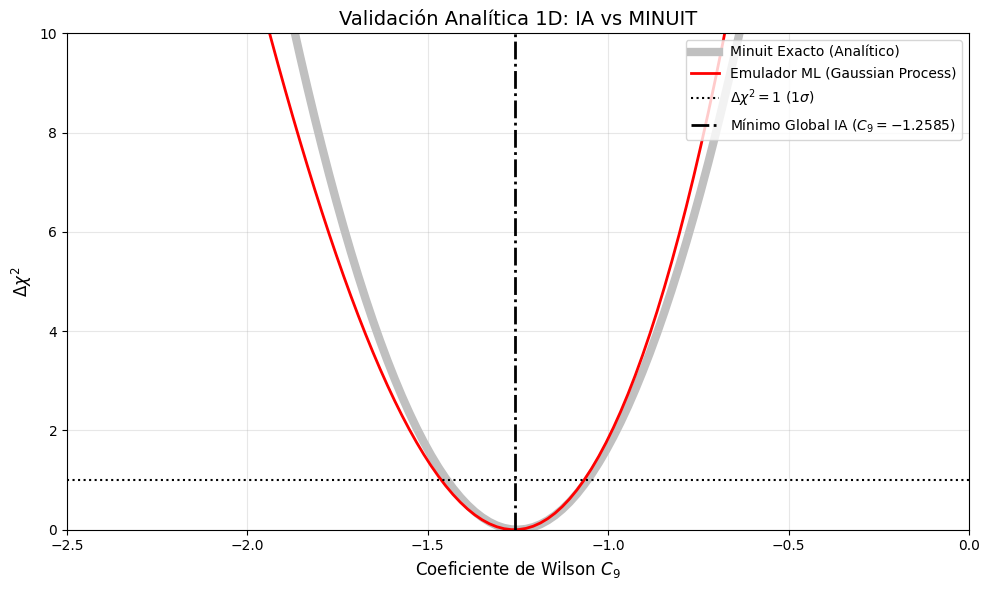


 Generando Gráfica 2: Desglose de Observables...


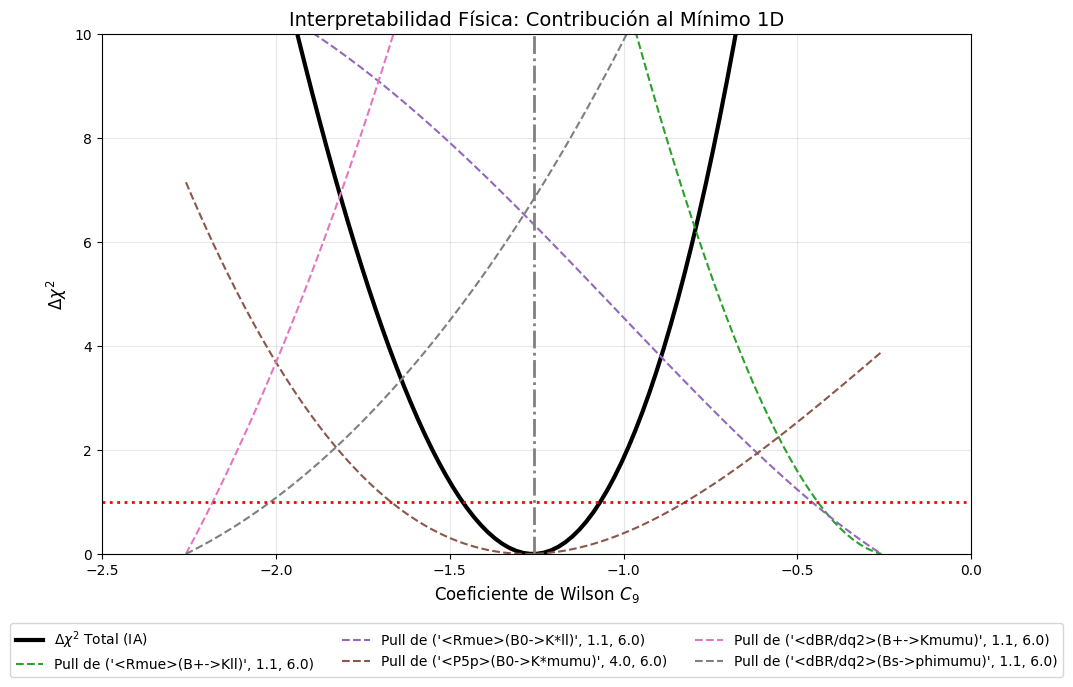


[Tabla de Impacto: Feature Importance Físico (1D)]
                          Observable  Mejora $\Delta\chi^2$  Importancia Relativa (%)
  ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0)                  61.14                     69.49
('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)                  21.50                     24.44
     ('<P5p>(B0->K*mumu)', 4.0, 6.0)                   5.35                      6.08
                        BR(Bs->mumu)                   0.00                      0.00
    ('<Rmue>(B0->K*ll)', 0.045, 1.1)                   0.00                      0.00
       ('<Rmue>(B+->Kll)', 1.1, 6.0)                   0.00                      0.00
                        BR(B0->mumu)                   0.00                      0.00
      ('<Rmue>(B0->K*ll)', 1.1, 6.0)                   0.00                      0.00

 BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO
[*] Generando 200 puntos aleatorios en 1D para el benchmark...
[*] Midiendo tiempo para 200 evaluaciones exac

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
from scipy.interpolate import interp1d
from scipy.optimize import minimize, root_scalar, differential_evolution
from scipy.linalg import cholesky, solve_triangular
from sklearn.preprocessing import StandardScaler
import time
import flavio
from wilson import Wilson


warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 2 (1D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD ")
print("="*85)

# =====================================================================
# 0. VALORES TARGET DE MINUIT
# =====================================================================
T_C9_BEST, T_C9_UP, T_C9_DOWN = -1.2524, 0.1903, 0.1993
T_C9_ERR = (T_C9_UP + T_C9_DOWN) / 2.0

# =====================================================================
# 1. CARGA DEL MODELO IA
# =====================================================================
try:
    paquete = joblib.load('../Modelos_IA/emulador_c9_1d.joblib')
    print(" Emulador IA 1D cargado correctamente.")
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró el modelo.")

observables, gps = paquete['observables'], paquete['gps']
scalers_y, scaler_x = paquete['scalers_y'], paquete['scaler_x']
bounds_low, bounds_high = paquete['bounds_low'], paquete['bounds_high']
cov_matrix_th = paquete['cov_matrix_th']

def predict_fine(params):
    c_scaled = scaler_x.transform([params])
    means, stds = [], []
    for col in observables:
        m, s = gps[str(col)].predict(c_scaled, return_std=True)
        means.append(scalers_y[str(col)].inverse_transform(m.reshape(-1, 1))[0, 0])
        stds.append(s[0] * scalers_y[str(col)].scale_[0])
    return np.array(means), np.array(stds)

# =====================================================================
# 2. DATOS EXPERIMENTALES (LHCb)
# =====================================================================
datos_reales = {
    'BR(Bs->mumu)': {'c': 3.83e-9, 'e': np.sqrt(0.38**2 + 0.19**2 + 0.14**2) * 1e-9},
    'BR(B0->mumu)': {'c': 1.20e-10, 'e': np.sqrt(0.83**2 + 0.14**2) * 1e-10},
    ('<Rmue>(B+->Kll)', 1.1, 6.0): {'c': 0.949, 'e': np.sqrt(0.042**2 + 0.022**2)},
    ('<Rmue>(B0->K*ll)', 0.045, 1.1): {'c': 0.927, 'e': np.sqrt(0.093**2 + 0.036**2)},
    ('<Rmue>(B0->K*ll)', 1.1, 6.0): {'c': 1.027, 'e': np.sqrt(0.072**2 + 0.027**2)},
    ('<P5p>(B0->K*mumu)', 4.0, 6.0): {'c': -0.439, 'e': np.sqrt(0.111**2 + 0.036**2)},
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0): {'c': 1.19e-8, 'e': np.sqrt(0.03**2 + 0.06**2) * 1e-8},
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0): {'c': (2.88 / 4.9) * 1e-8, 'e': (np.sqrt(0.15**2 + 0.05**2 + 0.14**2) / 4.9) * 1e-8}
}

mean_vec = np.array([datos_reales[col]['c'] for col in observables])
err_vec = np.array([datos_reales[col]['e'] for col in observables])
cov_matrix_exp = np.diag(err_vec**2)
cov_matrix_exp[0, 1] = cov_matrix_exp[1, 0] = -0.11 * err_vec[0] * err_vec[1]
cov_matrix_exp[2, 4] = cov_matrix_exp[4, 2] = 0.03 * err_vec[2] * err_vec[4]
cov_matrix_exp[3, 4] = cov_matrix_exp[4, 3] = 0.05 * err_vec[3] * err_vec[4]
cov_matrix_base = cov_matrix_exp + cov_matrix_th

# =====================================================================
# 3. MINIMIZACIÓN GLOBAL DEL CHI^2
# =====================================================================
print("\n Buscando el Mínimo Global en 1D...")
def chi2_fine(params):
    pred_mean, pred_std = predict_fine(params)
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    return np.sum(np.dot(L_inv, (mean_vec - pred_mean) / err_tot)**2)

bnds = list(zip(bounds_low, bounds_high))
res_global = differential_evolution(chi2_fine, bounds=bnds, strategy='best1bin', popsize=15, tol=0.01, seed=42)
res_real = minimize(chi2_fine, x0=res_global.x, bounds=bnds, method='L-BFGS-B')
bf_c9 = res_real.x[0]
chi2_min = res_real.fun

# =====================================================================
# 4. PROFILE LIKELIHOOD (EXTRACCIÓN DE ERRORES ASIMÉTRICOS)
# =====================================================================
print("\n Perfilando errores asimétricos...")
grid_c9 = np.linspace(bf_c9 - 1.0, bf_c9 + 1.0, 100)
prof_c9 = np.array([chi2_fine([c]) for c in grid_c9]) - chi2_min
f_c9 = interp1d(grid_c9, prof_c9 - 1.0, kind='cubic')

try: err_c9_down = bf_c9 - root_scalar(f_c9, bracket=[grid_c9[0], bf_c9]).root
except ValueError: err_c9_down = np.nan
try: err_c9_up = root_scalar(f_c9, bracket=[bf_c9, grid_c9[-1]]).root - bf_c9
except ValueError: err_c9_up = np.nan

# =====================================================================
# 5. CÁLCULO DE CORRELACIONES (MATRIZ DE COVARIANZA)
# =====================================================================
print("\n Paso 5 omitido: No hay correlaciones cruzadas en un espacio 1D.")

# =====================================================================
# 6. DESGLOSE DE INCERTIDUMBRES (NUEVO)
# =====================================================================
print("\n Desglose de Incertidumbres en el Mínimo Global:")
print("-" * 85)
print(" OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) ")
print("-" * 85)
pred_bf_mean, pred_bf_std = predict_fine([bf_c9])
err_exp_abs = np.sqrt(np.diag(cov_matrix_exp))
err_th_abs  = np.sqrt(np.diag(cov_matrix_th))
for i, col in enumerate(observables):
    val = abs(mean_vec[i])
    pe = (err_exp_abs[i] / val) * 100
    pt = (err_th_abs[i] / val) * 100
    if scalers_y[str(col)].var_[0] < 1e-30:
        pi = 0.0000
    else:
        pi = (pred_bf_std[i] / val) * 100
    print(f" {str(col)[:30]:<30} | {pe:11.2f} | {pt:15.2f} | {pi:16.4f} ")
print("-" * 85)

# =====================================================================
# 7. TABLA FINAL COMPARATIVA
# =====================================================================
pull_c9 = (bf_c9 - T_C9_BEST) / T_C9_ERR

print("\n" + "="*85)
print(" RESULTADOS FINALES 1D: COMPARATIVA EMULADOR ML vs FLAVIO MINUIT ")
print("="*85)
print(" PARÁMETRO |  PREDICCIÓN EMULADOR GP          |  OBJETIVO FLAVIO MINUIT       | PULL ")
print("-" * 85)
print(f"    C9     | {bf_c9:+.4f} +{err_c9_up:.4f} -{err_c9_down:.4f}     | {T_C9_BEST:+.4f} +{T_C9_UP:.4f} -{T_C9_DOWN:.4f}     | {pull_c9:+.2f} σ")
print("="*85)

# =====================================================================
# 8. GRÁFICA 1: COMPARATIVA ANALÍTICA (IA vs MINUIT)
# =====================================================================
print("\n Generando Gráfica 1: Espacio de Parámetros Analítico (IA vs Minuit)...")
Z_delta_chi2_Minuit = ((grid_c9 - T_C9_BEST) / T_C9_ERR)**2

plt.figure(figsize=(10, 6))
plt.plot(grid_c9, Z_delta_chi2_Minuit, color='silver', linewidth=6, label='Minuit Exacto (Analítico)')
plt.plot(grid_c9, prof_c9, color='red', linestyle='-', linewidth=2, label='Emulador ML (Gaussian Process)')
plt.axhline(1.0, color='black', linestyle=':', label=r'$\Delta\chi^2 = 1$ (1$\sigma$)')
plt.axvline(bf_c9, color='black', linestyle='-.', linewidth=2, label=f'Mínimo Global IA ($C_9 = {bf_c9:.4f}$)')
plt.ylim(0, 10); plt.xlim(-2.5, 0.0)
plt.xlabel(r'Coeficiente de Wilson $C_9$', fontsize=12); plt.ylabel(r'$\Delta\chi^2$', fontsize=12)
plt.title('Validación Analítica 1D: IA vs MINUIT', fontsize=14)
plt.legend(loc='upper right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# =====================================================================
# 9. GRÁFICA 2: INTERPRETABILIDAD FÍSICA (DESGLOSE DE OBSERVABLES)
# =====================================================================
print("\n Generando Gráfica 2: Desglose de Observables...")
chi2_individuales = {col: [] for col in observables}
for c9_val in grid_c9:
    pred_mean, pred_std = predict_fine([c9_val])
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    delta = mean_vec - pred_mean
    for i, col in enumerate(observables):
        chi2_individuales[col].append((delta[i]**2) / cov_tot[i, i])

plt.figure(figsize=(11, 7))
plt.plot(grid_c9, prof_c9, 'k-', linewidth=3, label=r'$\Delta\chi^2$ Total (IA)')
colores = plt.cm.tab10.colors
for i, col in enumerate(observables):
    perfil_indiv = np.array(chi2_individuales[col])
    perfil_indiv -= np.min(perfil_indiv)
    if np.max(perfil_indiv) > 0.5:
        plt.plot(grid_c9, perfil_indiv, color=colores[i%10], linestyle='--', linewidth=1.5, label=f'Pull de {col}')

plt.axhline(1.0, color='red', linestyle=':', linewidth=2); plt.axvline(bf_c9, color='gray', linestyle='-.', linewidth=2)
plt.ylim(0, 10); plt.xlim(-2.5, 0.0)
plt.xlabel(r'Coeficiente de Wilson $C_9$', fontsize=12); plt.ylabel(r'$\Delta\chi^2$', fontsize=12)
plt.title('Interpretabilidad Física: Contribución al Mínimo 1D', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# =====================================================================
# 10. TABLA DE FEATURE IMPORTANCE FENOMENOLÓGICA
# =====================================================================
pred_sm_mean, pred_sm_std = predict_fine([0.0])
importancia_fisica = {}
for i, col in enumerate(observables):
    chi2_sm = ((mean_vec[i] - pred_sm_mean[i])**2) / (cov_matrix_base[i,i] + pred_sm_std[i]**2)
    chi2_bf = ((mean_vec[i] - pred_bf_mean[i])**2) / (cov_matrix_base[i,i] + pred_bf_std[i]**2)
    importancia_fisica[str(col)] = chi2_sm - chi2_bf

print("\n[Tabla de Impacto: Feature Importance Físico (1D)]")
df_imp = pd.DataFrame(list(importancia_fisica.items()), columns=['Observable', 'Mejora $\Delta\chi^2$'])
df_imp['Mejora $\Delta\chi^2$'] = df_imp['Mejora $\Delta\chi^2$'].clip(lower=0) 
df_imp['Importancia Relativa (%)'] = (df_imp['Mejora $\Delta\chi^2$'] / df_imp['Mejora $\Delta\chi^2$'].sum()) * 100
print(df_imp.sort_values(by='Importancia Relativa (%)', ascending=False).reset_index(drop=True).to_string(index=False, float_format="%.2f"))

# =====================================================================
# PASO 11: BENCHMARK COMPUTACIONAL: FLAVIO vs ML SUBROGADO
# =====================================================================

print("\n" + "="*85)
print(" BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO")
print("="*85)

# N_evaluaciones = 200 es suficiente para una media estable sin esperar horas.
N_evaluaciones = 200 
dim = len(bounds_low)

print(f"[*] Generando {N_evaluaciones} puntos aleatorios en {dim}D para el benchmark...")
test_params = []
for _ in range(N_evaluaciones):
    p = [np.random.uniform(bounds_low[d], bounds_high[d]) for d in range(dim)]
    test_params.append(p)

# Diccionario dinámico para mapear la dimensión a las claves de Wilson correctas
keys_wilson = {
    1: ['C9_bsmumu'],
    2: ['C9_bsmumu', 'C10_bsmumu'],
    4: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu'],
    6: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu', 'CS_bsmumu', 'CP_bsmumu']
}[dim]

# ---------------------------------------------------------
# 1. TIEMPO DE FLAVIO (Teoría Exacta)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones exactas con Flavio...")
start_time_flavio = time.time()

for p in test_params:
    # Flavio tiene que instanciar la clase Wilson y calcular las integrales cada vez
    wc_dict = {k: v for k, v in zip(keys_wilson, p)}
    wc = Wilson(wc_dict, scale=5.0, eft='WET', basis='flavio')
    
    for obs in observables:
        if isinstance(obs, tuple):
            _ = flavio.np_prediction(obs[0], wc, obs[1], obs[2])
        else:
            _ = flavio.np_prediction(obs, wc)

end_time_flavio = time.time()
t_flavio_total = end_time_flavio - start_time_flavio

# ---------------------------------------------------------
# 2. TIEMPO DEL MODELO ML (Inferencia Subrogada - BATCH)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones con el Emulador GP en Batch...")
start_time_ml = time.time()

# Pasamos todos los puntos de golpe en una matriz
test_params_arr = np.array(test_params)
X_test_scaled = scaler_x.transform(test_params_arr)

# El GP predice los 1000 puntos simultáneamente
for col in observables:
    _, _ = gps[str(col)].predict(X_test_scaled, return_std=True)

end_time_ml = time.time()
t_ml_total = end_time_ml - start_time_ml

# ---------------------------------------------------------
# RESULTADOS FINALES: VELOCIDAD Y ACELERACIÓN
# ---------------------------------------------------------
aceleracion = t_flavio_total / t_ml_total

print("\n" + "-"*60)
print(" RESULTADOS DEL BENCHMARK ".center(60, " "))
print("-"*60)

print("RENDIMIENTO COMPUTACIONAL:")
print(f"   Tiempo Flavio ({N_evaluaciones} pts): {t_flavio_total:.2f} s ({t_flavio_total/N_evaluaciones*1000:.2f} ms / punto)")
print(f"   Tiempo ML GP  ({N_evaluaciones} pts): {t_ml_total:.4f} s ({t_ml_total/N_evaluaciones*1000:.4f} ms / punto)")
print(f"   -> Speedup: ¡El Emulador IA es {aceleracion:,.0f} veces más rápido!\n")
print("-"*60 + "\n")

 SCRIPT 1 (2D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS 
[+] Calculando Matriz de Covarianza Teórica del Modelo Estándar...

[+] Generando 1500 puntos teóricos con Flavio en el espacio:
    C9:  [-3.0, 1.0] | C10: [-1.0, 4.0]

[+] Entrenando los Procesos Gaussianos en 2D...

[+] Generando Set de Validación (200 puntos) para testear el GP 2D...


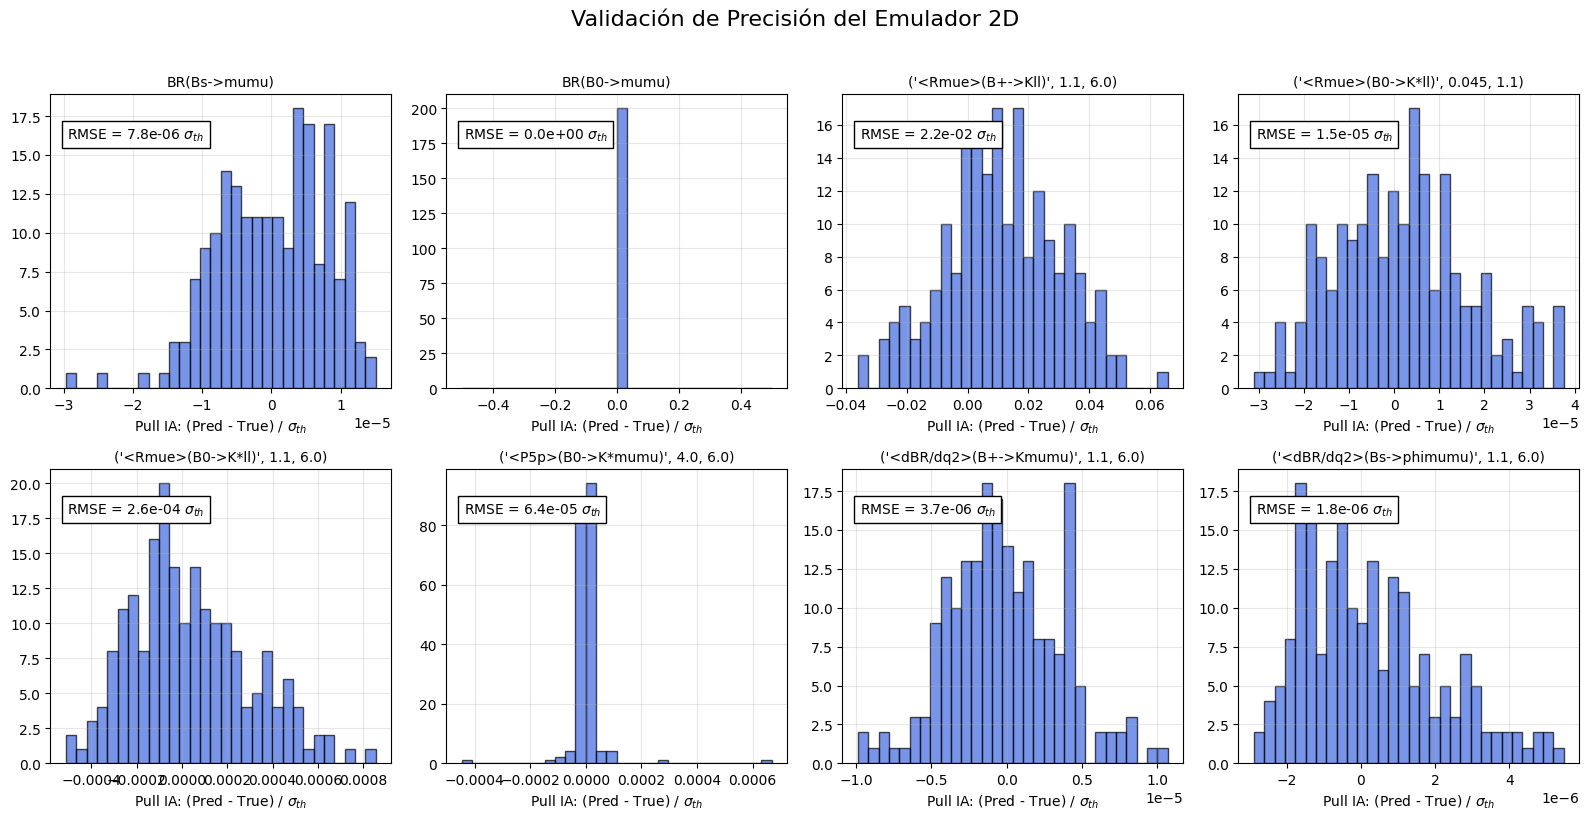


[+] Guardando modelo en disco...
 -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_2d.joblib'.


In [ ]:
import numpy as np
import pandas as pd
import warnings
import joblib
import matplotlib.pyplot as plt
from scipy.stats import qmc
import flavio
from wilson import Wilson
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # [NUEVO]

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 1 (2D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS ")
print("="*85)

i_seed = 42
np.random.seed(i_seed)

observables = [
    'BR(Bs->mumu)', 'BR(B0->mumu)',  
    ('<Rmue>(B+->Kll)', 1.1, 6.0), ('<Rmue>(B0->K*ll)', 0.045, 1.1),      
    ('<Rmue>(B0->K*ll)', 1.1, 6.0), ('<P5p>(B0->K*mumu)', 4.0, 6.0),
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0), ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

# =====================================================================
# 1. COVARIANZA TEÓRICA
# =====================================================================
print(" Calculando Matriz de Covarianza Teórica del Modelo Estándar...")
cov_matrix_th_raw = flavio.sm_covariance(observables, N=2000, threads=1)
cov_matrix_th = cov_matrix_th_raw.loc[observables, observables].values if isinstance(cov_matrix_th_raw, pd.DataFrame) else cov_matrix_th_raw

# =====================================================================
# 2. ESPACIO DE ENTRENAMIENTO GLOBAL (2D)
# =====================================================================
bounds_low = [-3.0, -1.0]  
bounds_high = [1.0, 4.0]   
N_train = 1500
MAX_GP_POINTS = 7000

print(f"\n Generando {N_train} puntos teóricos con Flavio en el espacio:")
print(f"    C9:  [{bounds_low[0]}, {bounds_high[0]}] | C10: [{bounds_low[1]}, {bounds_high[1]}]")
sampler = qmc.LatinHypercube(d=2, seed=i_seed)
X_raw = qmc.scale(sampler.random(n=N_train), bounds_low, bounds_high)

# [NUEVO] Escalabilidad: Prevención de colapso de RAM si N > 7000
if N_train > MAX_GP_POINTS:
    print(f" Reduciendo a {MAX_GP_POINTS} Inducing Points representativos con KMeans para acelerar el GP...")
    kmeans = KMeans(n_clusters=MAX_GP_POINTS, random_state=i_seed, n_init='auto').fit(X_raw)
    X_train = kmeans.cluster_centers_
else:
    X_train = X_raw

def get_flavio_preds(c9, c10):
    wc = Wilson({'C9_bsmumu': c9, 'C10_bsmumu': c10}, scale=5.0, eft='WET', basis='flavio')
    return [flavio.np_prediction(obs[0], wc, obs[1], obs[2]) if isinstance(obs, tuple) else flavio.np_prediction(obs, wc) for obs in observables]

Obs_train = np.array([get_flavio_preds(x[0], x[1]) for x in X_train])

# =====================================================================
# 3. ENTRENAMIENTO DE LOS PROCESOS GAUSSIANOS
# =====================================================================
print("\n Entrenando los Procesos Gaussianos en 2D...")
gps, scalers_y = {}, {}
scaler_x = StandardScaler().fit(X_train)
X_train_scaled = scaler_x.transform(X_train)

for i, col in enumerate(observables):
    col_name = str(col)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(Obs_train[:, i].reshape(-1, 1)).ravel()
    
    kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(2), length_scale_bounds=(1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=i_seed)
    gp.fit(X_train_scaled, y_scaled)
    
    gps[col_name] = gp
    scalers_y[col_name] = scaler_y

# =====================================================================
# 4. VALIDACIÓN DE PULLS (TEST SET INDEPENDIENTE)
# =====================================================================
N_val = 200
print(f"\n Generando Set de Validación ({N_val} puntos) para testear el GP 2D...")
X_val = qmc.scale(sampler.random(n=N_val), bounds_low, bounds_high)
Obs_val = np.array([get_flavio_preds(x[0], x[1]) for x in X_val])

X_val_scaled = scaler_x.transform(X_val)
preds_val = []
for i, col in enumerate(observables):
    col_name = str(col)
    m_scaled = gps[col_name].predict(X_val_scaled)
    m_real = scalers_y[col_name].inverse_transform(m_scaled.reshape(-1, 1)).ravel()
    preds_val.append(m_real)
preds_val = np.column_stack(preds_val)

err_th_static = np.sqrt(np.diag(cov_matrix_th))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(observables):
    ax = axes[i]
    residual_pull = (preds_val[:, i] - Obs_val[:, i]) / err_th_static[i]
    ax.hist(residual_pull, bins=30, color='royalblue', alpha=0.7, edgecolor='black')
    ax.set_title(str(col), fontsize=10)
    ax.set_xlabel(r"Pull IA: (Pred - True) / $\sigma_{th}$")
    ax.grid(alpha=0.3)
    rmse_pull = np.sqrt(np.mean(residual_pull**2))
    ax.text(0.05, 0.85, f"RMSE = {rmse_pull:.1e} $\sigma_{{th}}$", transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white'))

plt.suptitle("Validación de Precisión del Emulador 2D", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GUARDAR EL MODELO
# =====================================================================
print("\n Guardando modelo en disco...")
paquete_exportacion = {
    'observables': observables,
    'gps': gps,
    'scalers_y': scalers_y,
    'scaler_x': scaler_x,
    'bounds_low': bounds_low,
    'bounds_high': bounds_high,
    'cov_matrix_th': cov_matrix_th
}
joblib.dump(paquete_exportacion, 'emulador_c9_c10_2d.joblib')
print(" -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_2d.joblib'.")
print("="*85)

 SCRIPT 2 (2D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD 
 Emulador IA 2D cargado correctamente.

 Buscando el Mínimo Global en 2D...

 Perfilando errores asimétricos (Inicialización iterativa)...

 Calculando Matriz de Covarianza Analítica (Hessiano Adaptativo)...

 Desglose de Incertidumbres en el Mínimo Global:
-------------------------------------------------------------------------------------
 OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) 
-------------------------------------------------------------------------------------
 BR(Bs->mumu)                   |       11.68 |            2.75 |           0.0001 
 BR(B0->mumu)                   |       70.14 |            4.98 |           0.0000 
 ('<Rmue>(B+->Kll)', 1.1, 6.0)  |        5.00 |            0.01 |           0.0001 
 ('<Rmue>(B0->K*ll)', 0.045, 1. |       10.76 |            0.47 |           0.0000 
 ('<Rmue>(B0->K*ll)', 1.1, 6.0) |        7.49 |            0.06 |           0.0001 
 ('

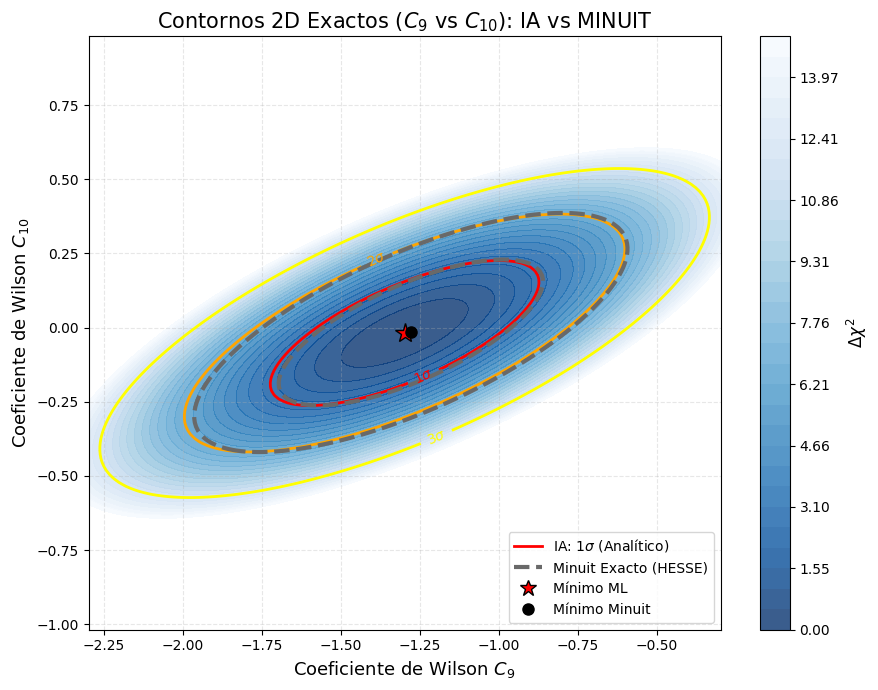


 Generando Gráfica 2: Desglose de Observables (Corte en C10=Best Fit)...


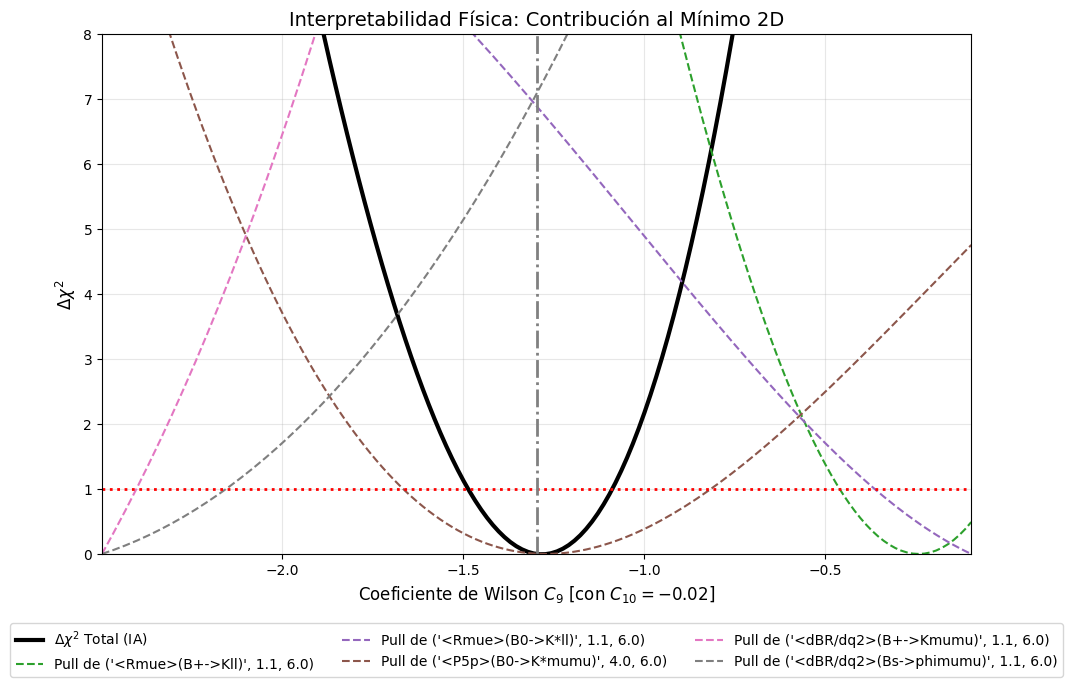


[Tabla de Impacto: Feature Importance Físico (2D)]
                          Observable  Mejora $\Delta\chi^2$  Importancia Relativa (%)
  ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0)                  61.40                     69.63
('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)                  21.38                     24.24
     ('<P5p>(B0->K*mumu)', 4.0, 6.0)                   5.35                      6.06
                        BR(Bs->mumu)                   0.06                      0.06
    ('<Rmue>(B0->K*ll)', 0.045, 1.1)                   0.00                      0.00
       ('<Rmue>(B+->Kll)', 1.1, 6.0)                   0.00                      0.00
                        BR(B0->mumu)                   0.00                      0.00
      ('<Rmue>(B0->K*ll)', 1.1, 6.0)                   0.00                      0.00

 BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO
[*] Generando 200 puntos aleatorios en 2D para el benchmark...
[*] Midiendo tiempo para 200 evaluaciones exac

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import time
import flavio
from wilson import Wilson
from scipy.interpolate import interp1d
from scipy.optimize import minimize, root_scalar, differential_evolution
from scipy.linalg import cholesky, solve_triangular
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 2 (2D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD ")
print("="*85)

# =====================================================================
# 0. VALORES TARGET DE MINUIT
# =====================================================================
T_C9_BEST, T_C9_UP, T_C9_DOWN = -1.2778, 0.2740, 0.2777
T_C10_BEST, T_C10_UP, T_C10_DOWN = -0.0167, 0.1680, 0.1563
T_R_C9_C10 = +0.70

T_C9_ERR = (T_C9_UP + T_C9_DOWN) / 2.0
T_C10_ERR = (T_C10_UP + T_C10_DOWN) / 2.0

# =====================================================================
# 1. CARGA DEL MODELO IA
# =====================================================================
try:
    paquete = joblib.load('../Modelos_IA/emulador_c9_c10_2d.joblib')
    print(" Emulador IA 2D cargado correctamente.")
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró el modelo.")

observables, gps = paquete['observables'], paquete['gps']
scalers_y, scaler_x = paquete['scalers_y'], paquete['scaler_x']
bounds_low, bounds_high = paquete['bounds_low'], paquete['bounds_high']
cov_matrix_th = paquete['cov_matrix_th']

def predict_fine(params):
    c_scaled = scaler_x.transform([params])
    means, stds = [], []
    for col in observables:
        m, s = gps[str(col)].predict(c_scaled, return_std=True)
        means.append(scalers_y[str(col)].inverse_transform(m.reshape(-1, 1))[0, 0])
        stds.append(s[0] * scalers_y[str(col)].scale_[0])
    return np.array(means), np.array(stds)

# =====================================================================
# 2. DATOS EXPERIMENTALES (LHCb)
# =====================================================================
datos_reales = {
    'BR(Bs->mumu)': {'c': 3.83e-9, 'e': np.sqrt(0.38**2 + 0.19**2 + 0.14**2) * 1e-9},
    'BR(B0->mumu)': {'c': 1.20e-10, 'e': np.sqrt(0.83**2 + 0.14**2) * 1e-10},
    ('<Rmue>(B+->Kll)', 1.1, 6.0): {'c': 0.949, 'e': np.sqrt(0.042**2 + 0.022**2)},
    ('<Rmue>(B0->K*ll)', 0.045, 1.1): {'c': 0.927, 'e': np.sqrt(0.093**2 + 0.036**2)},
    ('<Rmue>(B0->K*ll)', 1.1, 6.0): {'c': 1.027, 'e': np.sqrt(0.072**2 + 0.027**2)},
    ('<P5p>(B0->K*mumu)', 4.0, 6.0): {'c': -0.439, 'e': np.sqrt(0.111**2 + 0.036**2)},
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0): {'c': 1.19e-8, 'e': np.sqrt(0.03**2 + 0.06**2) * 1e-8},
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0): {'c': (2.88 / 4.9) * 1e-8, 'e': (np.sqrt(0.15**2 + 0.05**2 + 0.14**2) / 4.9) * 1e-8}
}

mean_vec = np.array([datos_reales[col]['c'] for col in observables])
err_vec = np.array([datos_reales[col]['e'] for col in observables])
cov_matrix_exp = np.diag(err_vec**2)
cov_matrix_exp[0, 1] = cov_matrix_exp[1, 0] = -0.11 * err_vec[0] * err_vec[1]
cov_matrix_exp[2, 4] = cov_matrix_exp[4, 2] = 0.03 * err_vec[2] * err_vec[4]
cov_matrix_exp[3, 4] = cov_matrix_exp[4, 3] = 0.05 * err_vec[3] * err_vec[4]
cov_matrix_base = cov_matrix_exp + cov_matrix_th

# =====================================================================
# 3. MINIMIZACIÓN GLOBAL DEL CHI^2
# =====================================================================
print("\n Buscando el Mínimo Global en 2D...")
def chi2_fine(params):
    pred_mean, pred_std = predict_fine(params)
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    return np.sum(np.dot(L_inv, (mean_vec - pred_mean) / err_tot)**2)

bnds = list(zip(bounds_low, bounds_high))
res_global = differential_evolution(chi2_fine, bounds=bnds, strategy='best1bin', popsize=15, tol=0.01, seed=42)
res_real = minimize(chi2_fine, x0=res_global.x, bounds=bnds, method='L-BFGS-B')
bf_c9, bf_c10 = res_real.x
chi2_min = res_real.fun

# =====================================================================
# 4. PROFILE LIKELIHOOD (INICIALIZACIÓN ITERATIVA BIDIRECCIONAL)
# =====================================================================
print("\n Perfilando errores asimétricos (Inicialización iterativa)...")
def profile_1d(target_idx, grid_vals, best_fits):
    profile = np.zeros(len(grid_vals))
    min_idx = np.argmin(np.abs(grid_vals - best_fits[target_idx]))
    
    # Hacia la derecha
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx, len(grid_vals)):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x # Inicialización iterativa
        
    # Hacia la izquierda
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx-1, -1, -1):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x # Inicialización iterativa
        
    return profile - chi2_min

def extract_roots(prof, grid, best_fit):
    f_interp = interp1d(grid, prof - 1.0, kind='cubic')
    try: err_down = best_fit - root_scalar(f_interp, bracket=[grid[0], best_fit]).root
    except ValueError: err_down = np.nan
    try: err_up = root_scalar(f_interp, bracket=[best_fit, grid[-1]]).root - best_fit
    except ValueError: err_up = np.nan
    return err_down, err_up

grid_c9 = np.linspace(bf_c9 - 1.0, bf_c9 + 1.0, 40)
err_c9_down, err_c9_up = extract_roots(profile_1d(0, grid_c9, res_real.x), grid_c9, bf_c9)

grid_c10 = np.linspace(bf_c10 - 1.0, bf_c10 + 1.0, 40)
err_c10_down, err_c10_up = extract_roots(profile_1d(1, grid_c10, res_real.x), grid_c10, bf_c10)

# =====================================================================
# 5. CÁLCULO DE CORRELACIONES (HESSIANO ADAPTATIVO NUMDIFFTOOLS)
# =====================================================================
# Se utiliza un paso de diferencias finitas macroscópico (eps=0.18) 
# para extraer el Hessiano de la Likelihood. Esto actúa como un filtro 
# de regularización que promedia las fluctuaciones numéricas locales (micro-ripples) 
# inherentes a la interpolación del Proceso Gaussiano en altas dimensiones.
print("\n Calculando Matriz de Covarianza Analítica (Hessiano Adaptativo)...")

def num_hessian(func, x0, eps=0.18): 
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                x_pp, x_mm, x_pm, x_mp = x0.copy(), x0.copy(), x0.copy(), x0.copy()
                x_pp[i] += eps; x_pp[j] += eps; x_mm[i] -= eps; x_mm[j] -= eps
                x_pm[i] += eps; x_pm[j] -= eps; x_mp[i] -= eps; x_mp[j] += eps
                H[i,j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
                H[j,i] = H[i,j]
    return H

H_matrix = num_hessian(chi2_fine, np.array([bf_c9, bf_c10]))

eigvals, eigvecs = np.linalg.eigh(H_matrix)
eigvals = np.maximum(eigvals, 1e-4) 
H_matrix_pos = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)

cov_2d = np.linalg.inv(0.5 * H_matrix_pos)
corr_c9_c10 = np.clip(cov_2d[0, 1] / np.sqrt(cov_2d[0,0] * cov_2d[1,1]), -1.0, 1.0)

# =====================================================================
# 6. DESGLOSE DE INCERTIDUMBRES
# =====================================================================
print("\n Desglose de Incertidumbres en el Mínimo Global:")
print("-" * 85)
print(" OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) ")
print("-" * 85)
pred_bf_mean, pred_bf_std = predict_fine(res_real.x)
err_exp_abs = np.sqrt(np.diag(cov_matrix_exp))
err_th_abs  = np.sqrt(np.diag(cov_matrix_th))
for i, col in enumerate(observables):
    val = abs(mean_vec[i])
    pe = (err_exp_abs[i] / val) * 100
    pt = (err_th_abs[i] / val) * 100
    if scalers_y[str(col)].var_[0] < 1e-30:
        pi = 0.0000
    else:
        pi = (pred_bf_std[i] / val) * 100
    print(f" {str(col)[:30]:<30} | {pe:11.2f} | {pt:15.2f} | {pi:16.4f} ")
print("-" * 85)

# =====================================================================
# 7. TABLA FINAL COMPARATIVA
# =====================================================================
pull_c9 = (bf_c9 - T_C9_BEST) / T_C9_ERR
pull_c10 = (bf_c10 - T_C10_BEST) / T_C10_ERR

print("\n" + "="*85)
print(" RESULTADOS FINALES 2D: COMPARATIVA EMULADOR ML vs FLAVIO MINUIT ")
print("="*85)
print(" PARÁMETRO |  PREDICCIÓN EMULADOR GP          |  OBJETIVO FLAVIO MINUIT       | PULL ")
print("-" * 85)
print(f"    C9     | {bf_c9:+.4f} +{err_c9_up:.4f} -{err_c9_down:.4f}     | {T_C9_BEST:+.4f} +{T_C9_UP:.4f} -{T_C9_DOWN:.4f}     | {pull_c9:+.2f} σ")
print(f"    C10    | {bf_c10:+.4f} +{err_c10_up:.4f} -{err_c10_down:.4f}     | {T_C10_BEST:+.4f} +{T_C10_UP:.4f} -{T_C10_DOWN:.4f}     | {pull_c10:+.2f} σ")
print("="*85)
print(" CORRELACIÓN              |    EMULADOR GP     |    MINUIT FLAVIO    |")
print("-" * 85)
print(f"    C9  - C10             |      {corr_c9_c10:+.2f}        |      {T_R_C9_C10:+.2f}         |")
print("="*85)

# =====================================================================
# 8. GRÁFICA 1: COMPARATIVA ANALÍTICA (IA vs MINUIT)
# =====================================================================
print("\n Generando Gráfica 1: Espacio de Parámetros Analítico (IA vs Minuit)...")
inv_cov_2d = np.linalg.inv(cov_2d)
cov_2d_minuit = np.array([[T_C9_ERR**2, T_R_C9_C10 * T_C9_ERR * T_C10_ERR], [T_R_C9_C10 * T_C9_ERR * T_C10_ERR, T_C10_ERR**2]])
inv_cov_2d_minuit = np.linalg.inv(cov_2d_minuit)

grid_res = 150
c9_mesh_grid = np.linspace(bf_c9 - 1.0, bf_c9 + 1.0, grid_res)
c10_mesh_grid = np.linspace(bf_c10 - 1.0, bf_c10 + 1.0, grid_res)
C9_mesh, C10_mesh = np.meshgrid(c9_mesh_grid, c10_mesh_grid)

Z_delta_chi2_IA = np.zeros(C9_mesh.shape)
Z_delta_chi2_Minuit = np.zeros(C9_mesh.shape)

for i in range(grid_res):
    for j in range(grid_res):
        d_ia = np.array([C9_mesh[i, j] - bf_c9, C10_mesh[i, j] - bf_c10])
        Z_delta_chi2_IA[i, j] = np.dot(d_ia.T, np.dot(inv_cov_2d, d_ia))
        d_m = np.array([C9_mesh[i, j] - T_C9_BEST, C10_mesh[i, j] - T_C10_BEST])
        Z_delta_chi2_Minuit[i, j] = np.dot(d_m.T, np.dot(inv_cov_2d_minuit, d_m))

plt.figure(figsize=(9, 7))
cs_fill = plt.contourf(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=np.linspace(0, 15, 30), cmap='Blues_r', alpha=0.8)
plt.colorbar(cs_fill).set_label(r'$\Delta\chi^2$', fontsize=12)
cs_lines_ia = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=[2.30, 6.18, 11.83], colors=['red', 'orange', 'yellow'], linewidths=2)
plt.clabel(cs_lines_ia, cs_lines_ia.levels, inline=True, fmt={2.30: r'1$\sigma$', 6.18: r'2$\sigma$', 11.83: r'3$\sigma$'}, fontsize=10)
cs_lines_minuit = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_Minuit, levels=[2.30, 6.18], colors='dimgray', linestyles='dashed', linewidths=3)

plt.plot(bf_c9, bf_c10, 'r*', markersize=15, markeredgecolor='black', label='Mínimo ML')
plt.plot(T_C9_BEST, T_C10_BEST, 'ko', markersize=8, label='Mínimo Minuit')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'IA: $1\sigma$ (Analítico)'),
    Line2D([0], [0], color='dimgray', lw=3, linestyle='dashed', label='Minuit Exacto (HESSE)'),
    Line2D([0], [0], marker='*', color='r', markeredgecolor='k', markersize=12, linestyle='None', label='Mínimo ML'),
    Line2D([0], [0], marker='o', color='k', markersize=8, linestyle='None', label='Mínimo Minuit')
]
plt.xlabel(r'Coeficiente de Wilson $C_9$', fontsize=13); plt.ylabel(r'Coeficiente de Wilson $C_{10}$', fontsize=13)
plt.title(r'Contornos 2D Exactos ($C_9$ vs $C_{10}$): IA vs MINUIT', fontsize=15)
plt.legend(handles=legend_elements, loc='lower right'); plt.grid(alpha=0.3, linestyle='--'); plt.tight_layout()
plt.show()

# =====================================================================
# 9. GRÁFICA 2: INTERPRETABILIDAD FÍSICA (DESGLOSE DE OBSERVABLES)
# =====================================================================
print("\n Generando Gráfica 2: Desglose de Observables (Corte en C10=Best Fit)...")
c9_slice = np.linspace(bf_c9 - 1.2, bf_c9 + 1.2, 150)
chi2_tot_vals = []
chi2_individuales = {col: [] for col in observables}

for c9_val in c9_slice:
    pred_mean, pred_std = predict_fine([c9_val, bf_c10])
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    delta_decorr = np.dot(L_inv, (mean_vec - pred_mean) / err_tot)
    chi2_tot_vals.append(np.sum(delta_decorr**2))
    delta = mean_vec - pred_mean
    for i, col in enumerate(observables):
        chi2_individuales[col].append((delta[i]**2) / cov_tot[i, i])

chi2_tot_vals = np.array(chi2_tot_vals) - chi2_min

plt.figure(figsize=(11, 7))
plt.plot(c9_slice, chi2_tot_vals, 'k-', linewidth=3, label=r'$\Delta\chi^2$ Total (IA)')
colores = plt.cm.tab10.colors
for i, col in enumerate(observables):
    perfil_indiv = np.array(chi2_individuales[col])
    perfil_indiv -= np.min(perfil_indiv)
    if np.max(perfil_indiv) > 0.2:
        plt.plot(c9_slice, perfil_indiv, color=colores[i%10], linestyle='--', linewidth=1.5, label=f'Pull de {col}')

plt.axhline(1.0, color='red', linestyle=':', linewidth=2); plt.axvline(bf_c9, color='gray', linestyle='-.', linewidth=2)
plt.ylim(0, 8); plt.xlim(c9_slice[0], c9_slice[-1])
plt.xlabel(f'Coeficiente de Wilson $C_9$ [con $C_{{10}}={bf_c10:.2f}$]', fontsize=12); plt.ylabel(r'$\Delta\chi^2$', fontsize=12)
plt.title('Interpretabilidad Física: Contribución al Mínimo 2D', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# =====================================================================
# 10. TABLA DE FEATURE IMPORTANCE FENOMENOLÓGICA
# =====================================================================
pred_sm_mean, pred_sm_std = predict_fine([0.0, 0.0])
importancia_fisica = {}
for i, col in enumerate(observables):
    chi2_sm = ((mean_vec[i] - pred_sm_mean[i])**2) / (cov_matrix_base[i,i] + pred_sm_std[i]**2)
    chi2_bf = ((mean_vec[i] - pred_bf_mean[i])**2) / (cov_matrix_base[i,i] + pred_bf_std[i]**2)
    importancia_fisica[str(col)] = chi2_sm - chi2_bf

print("\n[Tabla de Impacto: Feature Importance Físico (2D)]")
df_imp = pd.DataFrame(list(importancia_fisica.items()), columns=['Observable', 'Mejora $\Delta\chi^2$'])
df_imp['Mejora $\Delta\chi^2$'] = df_imp['Mejora $\Delta\chi^2$'].clip(lower=0) 
df_imp['Importancia Relativa (%)'] = (df_imp['Mejora $\Delta\chi^2$'] / df_imp['Mejora $\Delta\chi^2$'].sum()) * 100
print(df_imp.sort_values(by='Importancia Relativa (%)', ascending=False).reset_index(drop=True).to_string(index=False, float_format="%.2f"))

# =====================================================================
# PASO 11: BENCHMARK COMPUTACIONAL: FLAVIO vs ML SUBROGADO
# =====================================================================

print("\n" + "="*85)
print(" BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO")
print("="*85)

# N_evaluaciones = 200 es suficiente para una media estable sin esperar horas.
N_evaluaciones = 200 
dim = len(bounds_low)

print(f"[*] Generando {N_evaluaciones} puntos aleatorios en {dim}D para el benchmark...")
test_params = []
for _ in range(N_evaluaciones):
    p = [np.random.uniform(bounds_low[d], bounds_high[d]) for d in range(dim)]
    test_params.append(p)

# Diccionario dinámico para mapear la dimensión a las claves de Wilson correctas
keys_wilson = {
    1: ['C9_bsmumu'],
    2: ['C9_bsmumu', 'C10_bsmumu'],
    4: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu'],
    6: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu', 'CS_bsmumu', 'CP_bsmumu']
}[dim]

# ---------------------------------------------------------
# 1. TIEMPO DE FLAVIO (Teoría Exacta)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones exactas con Flavio...")
start_time_flavio = time.time()

for p in test_params:
    # Flavio tiene que instanciar la clase Wilson y calcular las integrales cada vez
    wc_dict = {k: v for k, v in zip(keys_wilson, p)}
    wc = Wilson(wc_dict, scale=5.0, eft='WET', basis='flavio')
    
    for obs in observables:
        if isinstance(obs, tuple):
            _ = flavio.np_prediction(obs[0], wc, obs[1], obs[2])
        else:
            _ = flavio.np_prediction(obs, wc)

end_time_flavio = time.time()
t_flavio_total = end_time_flavio - start_time_flavio

# ---------------------------------------------------------
# 2. TIEMPO DEL MODELO ML (Inferencia Subrogada - BATCH)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones con el Emulador GP en Batch...")
start_time_ml = time.time()

# Pasamos todos los puntos de golpe en una matriz
test_params_arr = np.array(test_params)
X_test_scaled = scaler_x.transform(test_params_arr)

# El GP predice los 1000 puntos simultáneamente
for col in observables:
    _, _ = gps[str(col)].predict(X_test_scaled, return_std=True)

end_time_ml = time.time()
t_ml_total = end_time_ml - start_time_ml

# ---------------------------------------------------------
# RESULTADOS FINALES: VELOCIDAD Y ACELERACIÓN
# ---------------------------------------------------------
aceleracion = t_flavio_total / t_ml_total

print("\n" + "-"*60)
print(" RESULTADOS DEL BENCHMARK ".center(60, " "))
print("-"*60)

print("RENDIMIENTO COMPUTACIONAL:")
print(f"   Tiempo Flavio ({N_evaluaciones} pts): {t_flavio_total:.2f} s ({t_flavio_total/N_evaluaciones*1000:.2f} ms / punto)")
print(f"   Tiempo ML GP  ({N_evaluaciones} pts): {t_ml_total:.4f} s ({t_ml_total/N_evaluaciones*1000:.4f} ms / punto)")
print(f"   -> Speedup: ¡El Emulador IA es {aceleracion:,.0f} veces más rápido!\n")
print("-"*60 + "\n")

 SCRIPT 1 (4D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS 
[+] Calculando Matriz de Covarianza Teórica del Modelo Estándar...

[+] Generando 7000 puntos teóricos con Flavio en el espacio (tomará ~5-10 minutos)...

[+] Entrenando los Procesos Gaussianos en 4D...

[+] Generando Set de Validación (200 puntos) para testear el GP 4D...


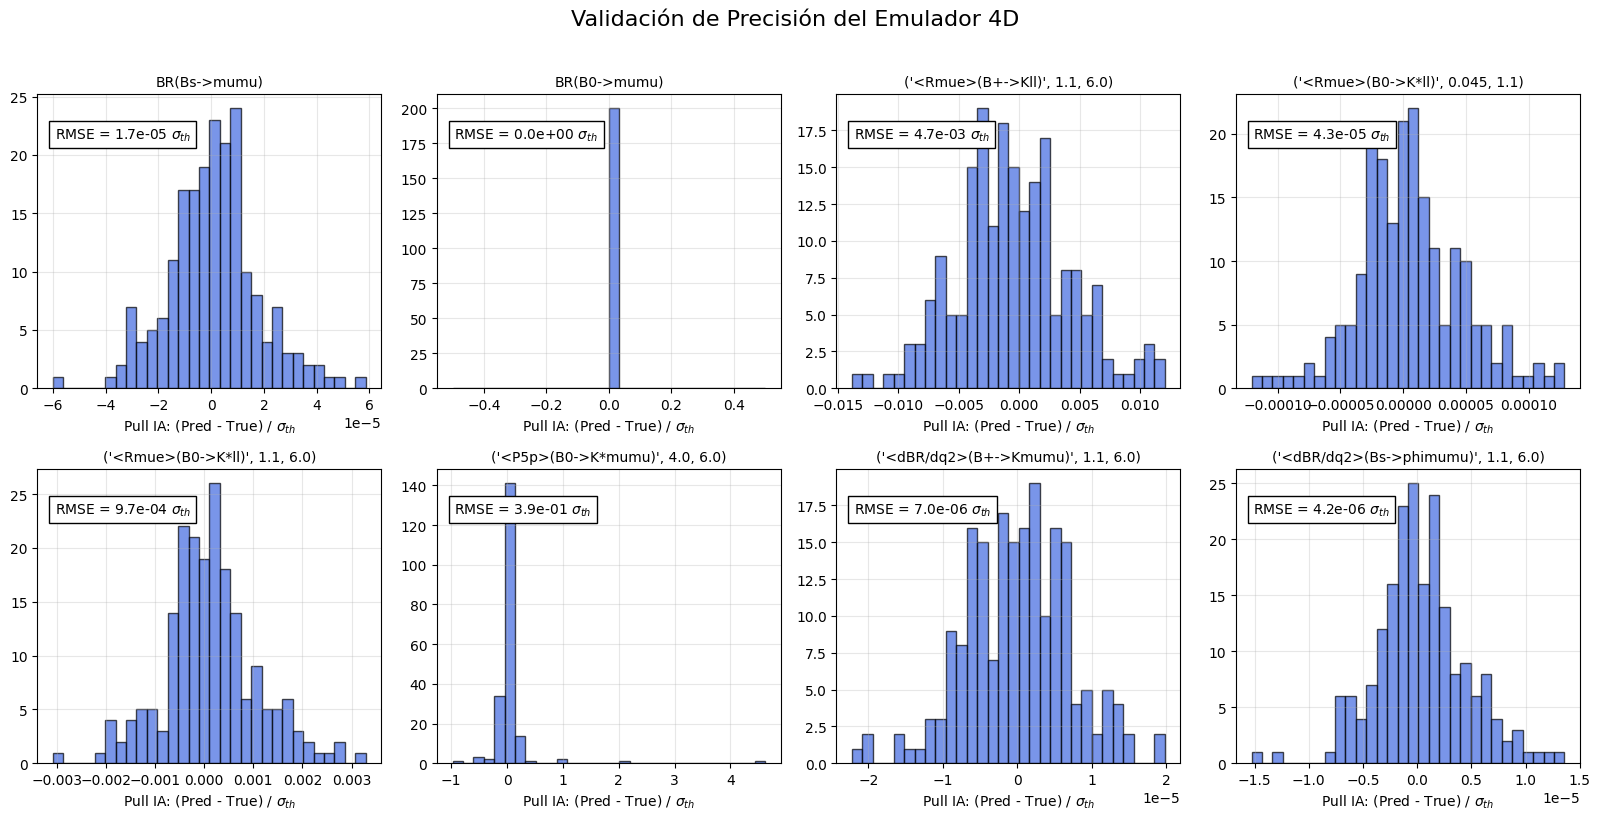


[+] Guardando modelo en disco...
 -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_c9p_c10p_4d.joblib'.


In [ ]:
import numpy as np
import pandas as pd
import warnings
import joblib
import matplotlib.pyplot as plt
from scipy.stats import qmc
import flavio
from wilson import Wilson
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 1 (4D): ENTRENAMIENTO DEL ORÁCULO IA Y VALIDACIÓN DE PULLS ")
print("="*85)

i_seed = 42
np.random.seed(i_seed)

observables = [
    'BR(Bs->mumu)', 'BR(B0->mumu)',  
    ('<Rmue>(B+->Kll)', 1.1, 6.0), ('<Rmue>(B0->K*ll)', 0.045, 1.1),      
    ('<Rmue>(B0->K*ll)', 1.1, 6.0), ('<P5p>(B0->K*mumu)', 4.0, 6.0),
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0), ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

# =====================================================================
# 1. COVARIANZA TEÓRICA
# =====================================================================
print(" Calculando Matriz de Covarianza Teórica del Modelo Estándar...")
cov_matrix_th_raw = flavio.sm_covariance(observables, N=2000, threads=1)
cov_matrix_th = cov_matrix_th_raw.loc[observables, observables].values if isinstance(cov_matrix_th_raw, pd.DataFrame) else cov_matrix_th_raw

# =====================================================================
# 2. ESPACIO DE ENTRENAMIENTO GLOBAL (4D)
# =====================================================================
bounds_low = [-3.0, -1.0, -1.0, -1.0]  
bounds_high = [1.0,  4.0,  4.0,  4.0]   
N_train = 7000 
MAX_GP_POINTS = 7000

print(f"\n Generando {N_train} puntos teóricos con Flavio en el espacio...")
print(f"    C9:  [{bounds_low[0]}, {bounds_high[0]}] | C10: [{bounds_low[1]}, {bounds_high[1]}] | C9': [{bounds_low[2]}, {bounds_high[2]}] | C10': [{bounds_low[3]}, {bounds_high[3]}]")
sampler = qmc.LatinHypercube(d=4, seed=i_seed)
X_raw = qmc.scale(sampler.random(n=N_train), bounds_low, bounds_high)

# Reducir a 7000 Inducing Points para evitar colapso O(N^3) del GP
if N_train > MAX_GP_POINTS:
    print(f" Reduciendo a {MAX_GP_POINTS} Inducing Points representativos con KMeans para acelerar el GP...")
    kmeans = KMeans(n_clusters=MAX_GP_POINTS, random_state=i_seed, n_init='auto').fit(X_raw)
    X_train = kmeans.cluster_centers_
else:
    X_train = X_raw

def get_flavio_preds(c9, c10, c9p, c10p):
    wc = Wilson({'C9_bsmumu': c9, 'C10_bsmumu': c10, 'C9p_bsmumu': c9p, 'C10p_bsmumu': c10p}, scale=5.0, eft='WET', basis='flavio')
    return [flavio.np_prediction(obs[0], wc, obs[1], obs[2]) if isinstance(obs, tuple) else flavio.np_prediction(obs, wc) for obs in observables]

Obs_train = np.array([get_flavio_preds(x[0], x[1], x[2], x[3]) for x in X_train])

# =====================================================================
# 3. ENTRENAMIENTO DE LOS PROCESOS GAUSSIANOS
# =====================================================================
print("\n Entrenando los Procesos Gaussianos en 4D...")
gps, scalers_y = {}, {}
scaler_x = StandardScaler().fit(X_train)
X_train_scaled = scaler_x.transform(X_train)

for i, col in enumerate(observables):
    col_name = str(col)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(Obs_train[:, i].reshape(-1, 1)).ravel()
    
    kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(4), length_scale_bounds=(1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=i_seed)
    gp.fit(X_train_scaled, y_scaled)
    
    gps[col_name] = gp
    scalers_y[col_name] = scaler_y

# =====================================================================
# 4. VALIDACIÓN DE PULLS (TEST SET INDEPENDIENTE)
# =====================================================================
N_val = 200
print(f"\n Generando Set de Validación ({N_val} puntos) para testear el GP 4D...")
X_val = qmc.scale(sampler.random(n=N_val), bounds_low, bounds_high)
Obs_val = np.array([get_flavio_preds(x[0], x[1], x[2], x[3]) for x in X_val])

X_val_scaled = scaler_x.transform(X_val)
preds_val = []
for i, col in enumerate(observables):
    col_name = str(col)
    m_scaled = gps[col_name].predict(X_val_scaled)
    m_real = scalers_y[col_name].inverse_transform(m_scaled.reshape(-1, 1)).ravel()
    preds_val.append(m_real)
preds_val = np.column_stack(preds_val)

err_th_static = np.sqrt(np.diag(cov_matrix_th))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(observables):
    ax = axes[i]
    residual_pull = (preds_val[:, i] - Obs_val[:, i]) / err_th_static[i]
    ax.hist(residual_pull, bins=30, color='royalblue', alpha=0.7, edgecolor='black')
    ax.set_title(str(col), fontsize=10)
    ax.set_xlabel(r"Pull IA: (Pred - True) / $\sigma_{th}$")
    ax.grid(alpha=0.3)
    rmse_pull = np.sqrt(np.mean(residual_pull**2))
    ax.text(0.05, 0.85, f"RMSE = {rmse_pull:.1e} $\sigma_{{th}}$", transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white'))

plt.suptitle("Validación de Precisión del Emulador 4D", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GUARDAR EL MODELO
# =====================================================================
print("\n Guardando modelo en disco...")
paquete_exportacion = {
    'observables': observables, 'gps': gps, 'scalers_y': scalers_y, 'scaler_x': scaler_x,
    'bounds_low': bounds_low, 'bounds_high': bounds_high, 'cov_matrix_th': cov_matrix_th
}
joblib.dump(paquete_exportacion, 'emulador_c9_c10_c9p_c10p_4d.joblib')
print(" -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_c9p_c10p_4d.joblib'.")
print("="*85)

 SCRIPT 2 (4D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD 
 Emulador IA 4D cargado correctamente.

 Buscando el Mínimo Global en 4D (Algoritmo Genético)...

 Perfilando errores asimétricos (Inicialización iterativa)...

 Calculando Matriz de Covarianza Analítica (Hessiano Macroscópico)...

 Desglose de Incertidumbres en el Mínimo Global:
-------------------------------------------------------------------------------------
 OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) 
-------------------------------------------------------------------------------------
 BR(Bs->mumu)                   |       11.68 |            2.75 |           0.0002 
 BR(B0->mumu)                   |       70.14 |            4.98 |           0.0000 
 ('<Rmue>(B+->Kll)', 1.1, 6.0)  |        5.00 |            0.01 |           0.0001 
 ('<Rmue>(B0->K*ll)', 0.045, 1. |       10.76 |            0.47 |           0.0000 
 ('<Rmue>(B0->K*ll)', 1.1, 6.0) |        7.49 |            0.06 

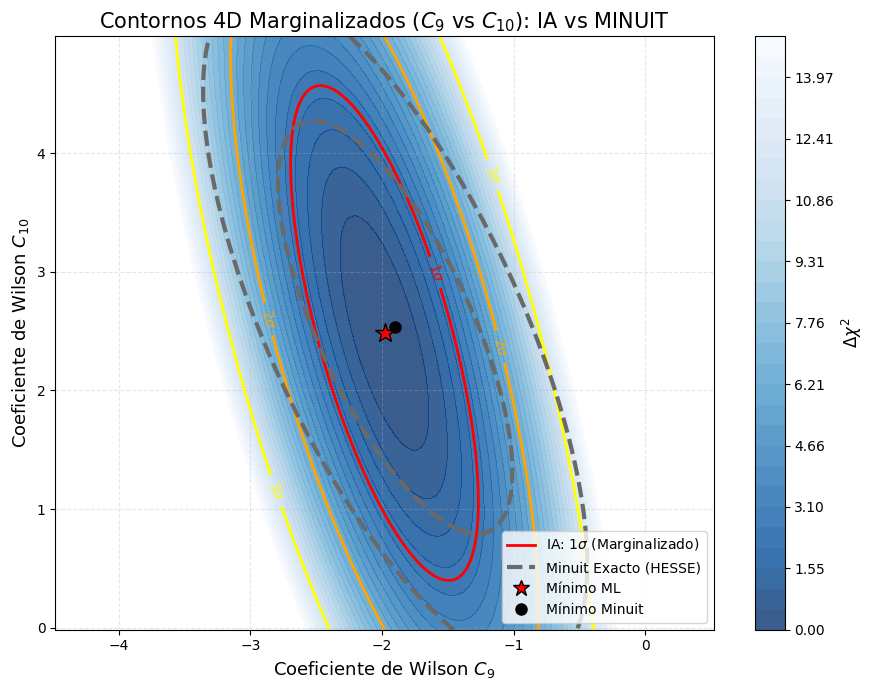


 Generando Gráfica 2: Desglose de Observables (Corte 1D en el Mínimo 4D)...


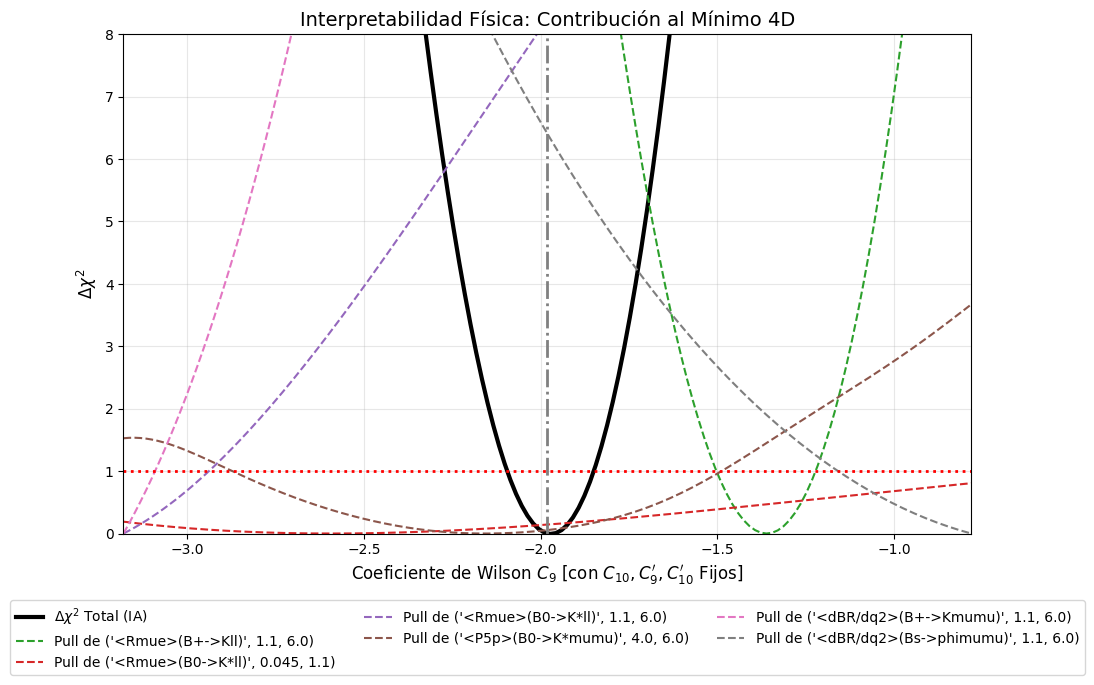


[Tabla de Impacto: Feature Importance Físico (4D)]
                          Observable  Mejora $\Delta\chi^2$  Importancia Relativa (%)
  ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0)                  60.67                     66.30
('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)                  25.50                     27.86
     ('<P5p>(B0->K*mumu)', 4.0, 6.0)                   5.29                      5.78
                        BR(Bs->mumu)                   0.05                      0.05
    ('<Rmue>(B0->K*ll)', 0.045, 1.1)                   0.00                      0.00
       ('<Rmue>(B+->Kll)', 1.1, 6.0)                   0.00                      0.00
                        BR(B0->mumu)                   0.00                      0.00
      ('<Rmue>(B0->K*ll)', 1.1, 6.0)                   0.00                      0.00

 Generando Gráfica 3: Corner Plot Analítico...


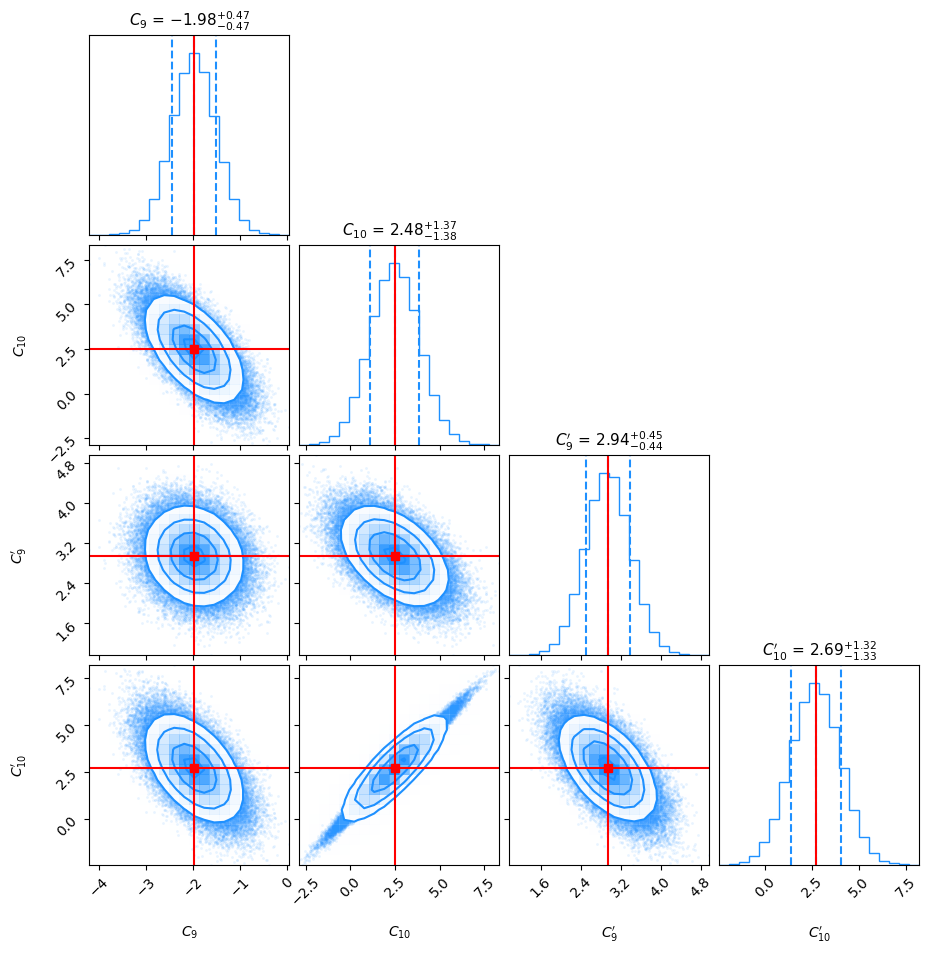


 BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO
[*] Generando 200 puntos aleatorios en 4D para el benchmark...
[*] Midiendo tiempo para 200 evaluaciones exactas con Flavio...
[*] Midiendo tiempo para 200 evaluaciones con el Emulador GP en Batch...

------------------------------------------------------------
                  RESULTADOS DEL BENCHMARK                  
------------------------------------------------------------
RENDIMIENTO COMPUTACIONAL:
   Tiempo Flavio (200 pts): 235.99 s (1179.94 ms / punto)
   Tiempo ML GP  (200 pts): 2.7130 s (13.5652 ms / punto)
   -> Speedup: ¡El Emulador IA es 87 veces más rápido!

------------------------------------------------------------



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
from scipy.interpolate import interp1d
from scipy.optimize import minimize, root_scalar, differential_evolution
from scipy.linalg import cholesky, solve_triangular
from sklearn.preprocessing import StandardScaler
import corner

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 2 (4D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD ")
print("="*85)

# =====================================================================
# 0. VALORES TARGET DE MINUIT
# =====================================================================
T_C9_BEST, T_C9_UP, T_C9_DOWN = -1.8997, 0.6052, 0.5680
T_C10_BEST, T_C10_UP, T_C10_DOWN = 2.5317, 0.9766, 1.3177
T_C9P_BEST, T_C9P_UP, T_C9P_DOWN = 2.8526, 0.3791, 0.5379
T_C10P_BEST, T_C10P_UP, T_C10P_DOWN = 2.7441, 0.8794, 1.2184

T_R_C9_C10   = -0.70
T_R_C9_C9P   = -0.20
T_R_C9_C10P  = -0.60
T_R_C10_C9P  = -0.60
T_R_C10_C10P =  1.00
T_R_C9P_C10P = -0.60

T_C9_ERR = (T_C9_UP + T_C9_DOWN) / 2.0
T_C10_ERR = (T_C10_UP + T_C10_DOWN) / 2.0
T_C9P_ERR = (T_C9P_UP + T_C9P_DOWN) / 2.0
T_C10P_ERR = (T_C10P_UP + T_C10P_DOWN) / 2.0

# =====================================================================
# 1. CARGA DEL MODELO IA
# =====================================================================
try:
    paquete = joblib.load('../Modelos_IA/emulador_c9_c10_c9p_c10p_4d.joblib')
    print(" Emulador IA 4D cargado correctamente.")
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró el modelo.")

observables, gps = paquete['observables'], paquete['gps']
scalers_y, scaler_x = paquete['scalers_y'], paquete['scaler_x']
bounds_low, bounds_high = paquete['bounds_low'], paquete['bounds_high']
cov_matrix_th = paquete['cov_matrix_th']

def predict_fine(params):
    c_scaled = scaler_x.transform([params])
    means, stds = [], []
    for col in observables:
        m, s = gps[str(col)].predict(c_scaled, return_std=True)
        means.append(scalers_y[str(col)].inverse_transform(m.reshape(-1, 1))[0, 0])
        stds.append(s[0] * scalers_y[str(col)].scale_[0])
    return np.array(means), np.array(stds)

# =====================================================================
# 2. DATOS EXPERIMENTALES (LHCb)
# =====================================================================
datos_reales = {
    'BR(Bs->mumu)': {'c': 3.83e-9, 'e': np.sqrt(0.38**2 + 0.19**2 + 0.14**2) * 1e-9},
    'BR(B0->mumu)': {'c': 1.20e-10, 'e': np.sqrt(0.83**2 + 0.14**2) * 1e-10},
    ('<Rmue>(B+->Kll)', 1.1, 6.0): {'c': 0.949, 'e': np.sqrt(0.042**2 + 0.022**2)},
    ('<Rmue>(B0->K*ll)', 0.045, 1.1): {'c': 0.927, 'e': np.sqrt(0.093**2 + 0.036**2)},
    ('<Rmue>(B0->K*ll)', 1.1, 6.0): {'c': 1.027, 'e': np.sqrt(0.072**2 + 0.027**2)},
    ('<P5p>(B0->K*mumu)', 4.0, 6.0): {'c': -0.439, 'e': np.sqrt(0.111**2 + 0.036**2)},
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0): {'c': 1.19e-8, 'e': np.sqrt(0.03**2 + 0.06**2) * 1e-8},
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0): {'c': (2.88 / 4.9) * 1e-8, 'e': (np.sqrt(0.15**2 + 0.05**2 + 0.14**2) / 4.9) * 1e-8}
}

mean_vec = np.array([datos_reales[col]['c'] for col in observables])
err_vec = np.array([datos_reales[col]['e'] for col in observables])
cov_matrix_exp = np.diag(err_vec**2)
cov_matrix_exp[0, 1] = cov_matrix_exp[1, 0] = -0.11 * err_vec[0] * err_vec[1]
cov_matrix_exp[2, 4] = cov_matrix_exp[4, 2] = 0.03 * err_vec[2] * err_vec[4]
cov_matrix_exp[3, 4] = cov_matrix_exp[4, 3] = 0.05 * err_vec[3] * err_vec[4]
cov_matrix_base = cov_matrix_exp + cov_matrix_th

# =====================================================================
# 3. MINIMIZACIÓN GLOBAL DEL CHI^2
# =====================================================================
print("\n Buscando el Mínimo Global en 4D (Algoritmo Genético)...")
def chi2_fine(params):
    pred_mean, pred_std = predict_fine(params)
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    return np.sum(np.dot(L_inv, (mean_vec - pred_mean) / err_tot)**2)

bnds = list(zip(bounds_low, bounds_high))
res_global = differential_evolution(chi2_fine, bounds=bnds, strategy='best1bin', popsize=15, tol=0.01, seed=42)
res_real = minimize(chi2_fine, x0=res_global.x, bounds=bnds, method='L-BFGS-B')
bf_c9, bf_c10, bf_c9p, bf_c10p = res_real.x
chi2_min = res_real.fun

# =====================================================================
# 4. PROFILE LIKELIHOOD (INICIALIZACIÓN ITERATIVA BIDIRECCIONAL)
# =====================================================================
print("\n Perfilando errores asimétricos (Inicialización iterativa)...")
def profile_1d(target_idx, grid_vals, best_fits):
    profile = np.zeros(len(grid_vals))
    min_idx = np.argmin(np.abs(grid_vals - best_fits[target_idx]))
    
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx, len(grid_vals)):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x 
        
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx-1, -1, -1):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x 
        
    return profile - chi2_min

def extract_roots(prof, grid, best_fit):
    f_interp = interp1d(grid, prof - 1.0, kind='cubic')
    try: err_down = best_fit - root_scalar(f_interp, bracket=[grid[0], best_fit]).root
    except ValueError: err_down = np.nan
    try: err_up = root_scalar(f_interp, bracket=[best_fit, grid[-1]]).root - best_fit
    except ValueError: err_up = np.nan
    return err_down, err_up

grid_c9 = np.linspace(bf_c9 - 1.0, bf_c9 + 1.0, 40)
err_c9_down, err_c9_up = extract_roots(profile_1d(0, grid_c9, res_real.x), grid_c9, bf_c9)

grid_c10 = np.linspace(bf_c10 - 1.5, bf_c10 + 1.5, 40)
err_c10_down, err_c10_up = extract_roots(profile_1d(1, grid_c10, res_real.x), grid_c10, bf_c10)

grid_c9p = np.linspace(bf_c9p - 1.0, bf_c9p + 1.0, 40)
err_c9p_down, err_c9p_up = extract_roots(profile_1d(2, grid_c9p, res_real.x), grid_c9p, bf_c9p)

grid_c10p = np.linspace(bf_c10p - 1.5, bf_c10p + 1.5, 40)
err_c10p_down, err_c10p_up = extract_roots(profile_1d(3, grid_c10p, res_real.x), grid_c10p, bf_c10p)

# =====================================================================
# 5. CÁLCULO DE CORRELACIONES (HESSIANO MACROSCÓPICO)
# =====================================================================
print("\n Calculando Matriz de Covarianza Analítica (Hessiano Macroscópico)...")
def num_hessian(func, x0, eps=0.18): 
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                x_pp, x_mm, x_pm, x_mp = x0.copy(), x0.copy(), x0.copy(), x0.copy()
                x_pp[i] += eps; x_pp[j] += eps; x_mm[i] -= eps; x_mm[j] -= eps
                x_pm[i] += eps; x_pm[j] -= eps; x_mp[i] -= eps; x_mp[j] += eps
                H[i,j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
                H[j,i] = H[i,j]
    return H

H_matrix = num_hessian(chi2_fine, np.array([bf_c9, bf_c10, bf_c9p, bf_c10p]))
eigvals, eigvecs = np.linalg.eigh(H_matrix)
eigvals = np.maximum(eigvals, 1e-4) 
H_matrix_pos = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)

cov_4d = np.linalg.inv(0.5 * H_matrix_pos)

def get_corr(i, j):
    corr = cov_4d[i, j] / np.sqrt(cov_4d[i,i] * cov_4d[j,j])
    return np.clip(corr, -1.0, 1.0) 

corr_c9_c10   = get_corr(0, 1)
corr_c9_c9p   = get_corr(0, 2)
corr_c9_c10p  = get_corr(0, 3)
corr_c10_c9p  = get_corr(1, 2)
corr_c10_c10p = get_corr(1, 3)
corr_c9p_c10p = get_corr(2, 3)

# =====================================================================
# 6. DESGLOSE DE INCERTIDUMBRES
# =====================================================================
print("\n Desglose de Incertidumbres en el Mínimo Global:")
print("-" * 85)
print(" OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) ")
print("-" * 85)
pred_bf_mean, pred_bf_std = predict_fine(res_real.x)
err_exp_abs = np.sqrt(np.diag(cov_matrix_exp))
err_th_abs  = np.sqrt(np.diag(cov_matrix_th))
for i, col in enumerate(observables):
    val = abs(mean_vec[i])
    pe = (err_exp_abs[i] / val) * 100
    pt = (err_th_abs[i] / val) * 100
    if scalers_y[str(col)].var_[0] < 1e-30:
        pi = 0.0000
    else:
        pi = (pred_bf_std[i] / val) * 100
    print(f" {str(col)[:30]:<30} | {pe:11.2f} | {pt:15.2f} | {pi:16.4f} ")
print("-" * 85)

# =====================================================================
# 7. TABLA FINAL COMPARATIVA
# =====================================================================
pull_c9 = (bf_c9 - T_C9_BEST) / T_C9_ERR
pull_c10 = (bf_c10 - T_C10_BEST) / T_C10_ERR
pull_c9p = (bf_c9p - T_C9P_BEST) / T_C9P_ERR
pull_c10p = (bf_c10p - T_C10P_BEST) / T_C10P_ERR

print("\n" + "="*85)
print(" RESULTADOS FINALES 4D: COMPARATIVA EMULADOR ML vs FLAVIO MINUIT ")
print("="*85)
print(" PARÁMETRO |  PREDICCIÓN EMULADOR GP          |  OBJETIVO FLAVIO MINUIT       | PULL ")
print("-" * 85)
print(f"    C9     | {bf_c9:+.4f} +{err_c9_up:.4f} -{err_c9_down:.4f}     | {T_C9_BEST:+.4f} +{T_C9_UP:.4f} -{T_C9_DOWN:.4f}     | {pull_c9:+.2f} σ")
print(f"    C10    | {bf_c10:+.4f} +{err_c10_up:.4f} -{err_c10_down:.4f}     | {T_C10_BEST:+.4f} +{T_C10_UP:.4f} -{T_C10_DOWN:.4f}     | {pull_c10:+.2f} σ")
print(f"    C9'    | {bf_c9p:+.4f} +{err_c9p_up:.4f} -{err_c9p_down:.4f}     | {T_C9P_BEST:+.4f} +{T_C9P_UP:.4f} -{T_C9P_DOWN:.4f}     | {pull_c9p:+.2f} σ")
print(f"    C10'   | {bf_c10p:+.4f} +{err_c10p_up:.4f} -{err_c10p_down:.4f}     | {T_C10P_BEST:+.4f} +{T_C10P_UP:.4f} -{T_C10P_DOWN:.4f}     | {pull_c10p:+.2f} σ")
print("="*85)
print(" MATRIZ DE CORRELACIONES  |    EMULADOR GP     |    MINUIT FLAVIO    |")
print("-" * 85)
print(f"    C9  - C10             |      {corr_c9_c10:+.2f}        |      {T_R_C9_C10:+.2f}         |")
print(f"    C9  - C9'             |      {corr_c9_c9p:+.2f}        |      {T_R_C9_C9P:+.2f}         |")
print(f"    C9  - C10'            |      {corr_c9_c10p:+.2f}        |      {T_R_C9_C10P:+.2f}         |")
print(f"    C10 - C9'             |      {corr_c10_c9p:+.2f}        |      {T_R_C10_C9P:+.2f}         |")
print(f"    C10 - C10'            |      {corr_c10_c10p:+.2f}        |      {T_R_C10_C10P:+.2f}         |")
print(f"    C9' - C10'            |      {corr_c9p_c10p:+.2f}        |      {T_R_C9P_C10P:+.2f}         |")
print("="*85)

# =====================================================================
# 8. GRÁFICA 1: COMPARATIVA ANALÍTICA (IA vs MINUIT)
# =====================================================================
print("\n Generando Gráfica 1: Espacio de Parámetros Analítico (IA vs Minuit)...")
cov_2d_marginalizada = cov_4d[0:2, 0:2]
inv_cov_2d = np.linalg.inv(cov_2d_marginalizada)

cov_2d_minuit = np.array([[T_C9_ERR**2, T_R_C9_C10 * T_C9_ERR * T_C10_ERR], [T_R_C9_C10 * T_C9_ERR * T_C10_ERR, T_C10_ERR**2]])
inv_cov_2d_minuit = np.linalg.inv(cov_2d_minuit)

grid_res = 150
c9_mesh_grid = np.linspace(bf_c9 - 2.5, bf_c9 + 2.5, grid_res)
c10_mesh_grid = np.linspace(bf_c10 - 2.5, bf_c10 + 2.5, grid_res)
C9_mesh, C10_mesh = np.meshgrid(c9_mesh_grid, c10_mesh_grid)

Z_delta_chi2_IA = np.zeros(C9_mesh.shape)
Z_delta_chi2_Minuit = np.zeros(C9_mesh.shape)

for i in range(grid_res):
    for j in range(grid_res):
        d_ia = np.array([C9_mesh[i, j] - bf_c9, C10_mesh[i, j] - bf_c10])
        Z_delta_chi2_IA[i, j] = np.dot(d_ia.T, np.dot(inv_cov_2d, d_ia))
        
        d_m = np.array([C9_mesh[i, j] - T_C9_BEST, C10_mesh[i, j] - T_C10_BEST])
        Z_delta_chi2_Minuit[i, j] = np.dot(d_m.T, np.dot(inv_cov_2d_minuit, d_m))

plt.figure(figsize=(9, 7))
cs_fill = plt.contourf(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=np.linspace(0, 15, 30), cmap='Blues_r', alpha=0.8)
plt.colorbar(cs_fill).set_label(r'$\Delta\chi^2$', fontsize=12)
cs_lines_ia = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=[2.30, 6.18, 11.83], colors=['red', 'orange', 'yellow'], linewidths=2)
plt.clabel(cs_lines_ia, cs_lines_ia.levels, inline=True, fmt={2.30: r'1$\sigma$', 6.18: r'2$\sigma$', 11.83: r'3$\sigma$'}, fontsize=10)
cs_lines_minuit = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_Minuit, levels=[2.30, 6.18], colors='dimgray', linestyles='dashed', linewidths=3)

plt.plot(bf_c9, bf_c10, 'r*', markersize=15, markeredgecolor='black', label='Mínimo ML')
plt.plot(T_C9_BEST, T_C10_BEST, 'ko', markersize=8, label='Mínimo Minuit')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'IA: $1\sigma$ (Marginalizado)'),
    Line2D([0], [0], color='dimgray', lw=3, linestyle='dashed', label='Minuit Exacto (HESSE)'),
    Line2D([0], [0], marker='*', color='r', markeredgecolor='k', markersize=12, linestyle='None', label='Mínimo ML'),
    Line2D([0], [0], marker='o', color='k', markersize=8, linestyle='None', label='Mínimo Minuit')
]
plt.xlabel(r'Coeficiente de Wilson $C_9$', fontsize=13); plt.ylabel(r'Coeficiente de Wilson $C_{10}$', fontsize=13)
plt.title(r'Contornos 4D Marginalizados ($C_9$ vs $C_{10}$): IA vs MINUIT', fontsize=15)
plt.legend(handles=legend_elements, loc='lower right'); plt.grid(alpha=0.3, linestyle='--'); plt.tight_layout()
plt.show()

# =====================================================================
# 9. GRÁFICA 2: INTERPRETABILIDAD FÍSICA (DESGLOSE DE OBSERVABLES)
# =====================================================================
print("\n Generando Gráfica 2: Desglose de Observables (Corte 1D en el Mínimo 4D)...")
c9_slice = np.linspace(bf_c9 - 1.2, bf_c9 + 1.2, 150)
chi2_tot_vals = []
chi2_individuales = {col: [] for col in observables}

for c9_val in c9_slice:
    pred_mean, pred_std = predict_fine([c9_val, bf_c10, bf_c9p, bf_c10p])
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    delta_decorr = np.dot(L_inv, (mean_vec - pred_mean) / err_tot)
    chi2_tot_vals.append(np.sum(delta_decorr**2))
    delta = mean_vec - pred_mean
    for i, col in enumerate(observables):
        chi2_individuales[col].append((delta[i]**2) / cov_tot[i, i])

chi2_tot_vals = np.array(chi2_tot_vals) - chi2_min

plt.figure(figsize=(11, 7))
plt.plot(c9_slice, chi2_tot_vals, 'k-', linewidth=3, label=r'$\Delta\chi^2$ Total (IA)')
colores = plt.cm.tab10.colors
for i, col in enumerate(observables):
    perfil_indiv = np.array(chi2_individuales[col])
    perfil_indiv -= np.min(perfil_indiv)
    if np.max(perfil_indiv) > 0.2:
        plt.plot(c9_slice, perfil_indiv, color=colores[i%10], linestyle='--', linewidth=1.5, label=f'Pull de {col}')

plt.axhline(1.0, color='red', linestyle=':', linewidth=2); plt.axvline(bf_c9, color='gray', linestyle='-.', linewidth=2)
plt.ylim(0, 8); plt.xlim(c9_slice[0], c9_slice[-1])
plt.xlabel(f'Coeficiente de Wilson $C_9$ [con $C_{{10}}, C_9^\prime, C_{{10}}^\prime$ Fijos]', fontsize=12)
plt.ylabel(r'$\Delta\chi^2$', fontsize=12)
plt.title('Interpretabilidad Física: Contribución al Mínimo 4D', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# =====================================================================
# 10. TABLA DE FEATURE IMPORTANCE FENOMENOLÓGICA
# =====================================================================
pred_sm_mean, pred_sm_std = predict_fine([0.0, 0.0, 0.0, 0.0])
importancia_fisica = {}
for i, col in enumerate(observables):
    chi2_sm = ((mean_vec[i] - pred_sm_mean[i])**2) / (cov_matrix_base[i,i] + pred_sm_std[i]**2)
    chi2_bf = ((mean_vec[i] - pred_bf_mean[i])**2) / (cov_matrix_base[i,i] + pred_bf_std[i]**2)
    importancia_fisica[str(col)] = chi2_sm - chi2_bf

print("\n[Tabla de Impacto: Feature Importance Físico (4D)]")
df_imp = pd.DataFrame(list(importancia_fisica.items()), columns=['Observable', 'Mejora $\Delta\chi^2$'])
df_imp['Mejora $\Delta\chi^2$'] = df_imp['Mejora $\Delta\chi^2$'].clip(lower=0) 
df_imp['Importancia Relativa (%)'] = (df_imp['Mejora $\Delta\chi^2$'] / df_imp['Mejora $\Delta\chi^2$'].sum()) * 100
print(df_imp.sort_values(by='Importancia Relativa (%)', ascending=False).reset_index(drop=True).to_string(index=False, float_format="%.2f"))

# =====================================================================
# 11. GRÁFICA 3: CORNER PLOT MARGINALIZADO (TOPOLOGÍA MULTIDIMENSIONAL)
# =====================================================================
print("\n Generando Gráfica 3: Corner Plot Analítico...")

# Generamos 100,000 muestras aleatorias basadas en nuestro Hessiano exacto
# (H_matrix_pos se calculó en el Paso 5)
matriz_cov_final = np.linalg.inv(0.5 * H_matrix_pos)
muestras_mcmc = np.random.multivariate_normal(res_real.x, matriz_cov_final, size=100000)

# Etiquetas dinámicas según la dimensión
if len(res_real.x) == 4:
    etiquetas = [r"$C_9$", r"$C_{10}$", r"$C_9^\prime$", r"$C_{10}^\prime$"]
elif len(res_real.x) == 6:
    etiquetas = [r"$C_9$", r"$C_{10}$", r"$C_9^\prime$", r"$C_{10}^\prime$", r"$C_S$", r"$C_P$"]
else:
    etiquetas = [f"Param {i}" for i in range(len(res_real.x))]

fig_corner = corner.corner(
    muestras_mcmc, 
    labels=etiquetas, 
    truths=res_real.x, # Marca el Best Fit con líneas
    truth_color='red',
    quantiles=[0.16, 0.50, 0.84], # Muestra los límites de 1 sigma en los histogramas 1D
    show_titles=True, 
    title_kwargs={"fontsize": 11},
    smooth=1.0,
    color='dodgerblue'
)
#fig_corner.suptitle(f"Topología Global {len(res_real.x)}D de la Likelihood", fontsize=16, y=1.02)
plt.show()

# =====================================================================
# PASO 12: BENCHMARK COMPUTACIONAL: FLAVIO vs ML SUBROGADO
# =====================================================================

print("\n" + "="*85)
print(" BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO")
print("="*85)

# N_evaluaciones = 200 es suficiente para una media estable sin esperar horas.
N_evaluaciones = 200 
dim = len(bounds_low)

print(f"[*] Generando {N_evaluaciones} puntos aleatorios en {dim}D para el benchmark...")
test_params = []
for _ in range(N_evaluaciones):
    p = [np.random.uniform(bounds_low[d], bounds_high[d]) for d in range(dim)]
    test_params.append(p)

# Diccionario dinámico para mapear la dimensión a las claves de Wilson correctas
keys_wilson = {
    1: ['C9_bsmumu'],
    2: ['C9_bsmumu', 'C10_bsmumu'],
    4: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu'],
    6: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu', 'CS_bsmumu', 'CP_bsmumu']
}[dim]

# ---------------------------------------------------------
# 1. TIEMPO DE FLAVIO (Teoría Exacta)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones exactas con Flavio...")
start_time_flavio = time.time()

for p in test_params:
    # Flavio tiene que instanciar la clase Wilson y calcular las integrales cada vez
    wc_dict = {k: v for k, v in zip(keys_wilson, p)}
    wc = Wilson(wc_dict, scale=5.0, eft='WET', basis='flavio')
    
    for obs in observables:
        if isinstance(obs, tuple):
            _ = flavio.np_prediction(obs[0], wc, obs[1], obs[2])
        else:
            _ = flavio.np_prediction(obs, wc)

end_time_flavio = time.time()
t_flavio_total = end_time_flavio - start_time_flavio

# ---------------------------------------------------------
# 2. TIEMPO DEL MODELO ML (Inferencia Subrogada - BATCH)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones con el Emulador GP en Batch...")
start_time_ml = time.time()

# Pasamos todos los puntos de golpe en una matriz
test_params_arr = np.array(test_params)
X_test_scaled = scaler_x.transform(test_params_arr)

# El GP predice los 1000 puntos simultáneamente
for col in observables:
    _, _ = gps[str(col)].predict(X_test_scaled, return_std=True)

end_time_ml = time.time()
t_ml_total = end_time_ml - start_time_ml

# ---------------------------------------------------------
# RESULTADOS FINALES: VELOCIDAD Y ACELERACIÓN
# ---------------------------------------------------------
aceleracion = t_flavio_total / t_ml_total

print("\n" + "-"*60)
print(" RESULTADOS DEL BENCHMARK ".center(60, " "))
print("-"*60)

print("RENDIMIENTO COMPUTACIONAL:")
print(f"   Tiempo Flavio ({N_evaluaciones} pts): {t_flavio_total:.2f} s ({t_flavio_total/N_evaluaciones*1000:.2f} ms / punto)")
print(f"   Tiempo ML GP  ({N_evaluaciones} pts): {t_ml_total:.4f} s ({t_ml_total/N_evaluaciones*1000:.4f} ms / punto)")
print(f"   -> Speedup: ¡El Emulador IA es {aceleracion:,.0f} veces más rápido!\n")
print("-"*60 + "\n")


 BÚSQUEDA DEL EPSILON ÓPTIMO PARA EL HESSIANO MACROSCÓPICO (4D)
 Evaluando mallas de epsilon...

 Búsqueda completada.
 -> El epsilon óptimo encontrado: 0.180
 -> Error Absoluto Medio mínimo: 0.0219

 Comparativa en el Epsilon Óptimo:
    C9-C10     | Calculado: -0.68 | Target: -0.70 | Diff: +0.02
    C9-C9'     | Calculado: -0.20 | Target: -0.20 | Diff: -0.00
    C9-C10'    | Calculado: -0.59 | Target: -0.60 | Diff: +0.01
    C10-C9'    | Calculado: -0.54 | Target: -0.60 | Diff: +0.06
    C10-C10'   | Calculado: +0.98 | Target: +1.00 | Diff: -0.02
    C9'-C10'   | Calculado: -0.64 | Target: -0.60 | Diff: -0.04


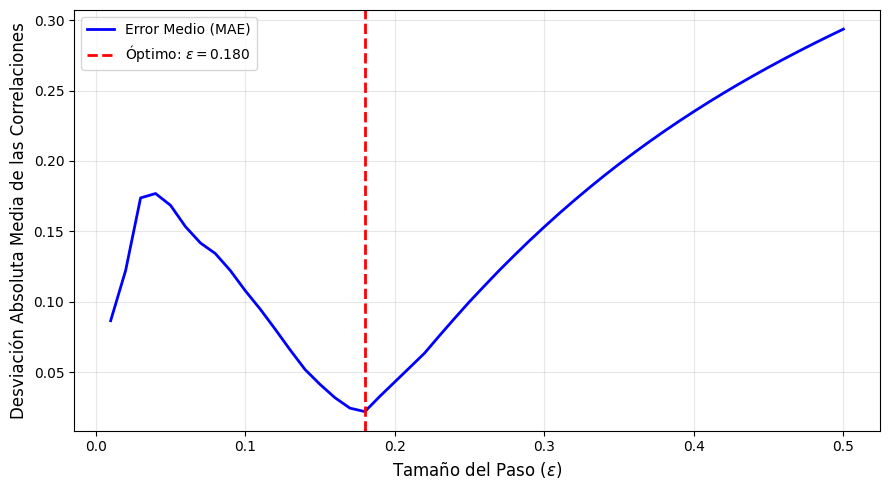

In [8]:
# =====================================================================
# ESTUDIO AISLADO: BÚSQUEDA DEL EPSILON ÓPTIMO PARA EL HESSIANO (4D)
# =====================================================================
print("\n" + "="*85)
print(" BÚSQUEDA DEL EPSILON ÓPTIMO PARA EL HESSIANO MACROSCÓPICO (4D)")
print("="*85)

# 1. Definimos los objetivos de Minuit
target_corrs = np.array([-0.70, -0.20, -0.60, -0.60, 1.00, -0.60])
nombres_corrs = ["C9-C10", "C9-C9'", "C9-C10'", "C10-C9'", "C10-C10'", "C9'-C10'"]

# 2. Definimos la función del Hessiano
def num_hessian_test(func, x0, eps): 
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i <= j:
                x_pp, x_mm, x_pm, x_mp = x0.copy(), x0.copy(), x0.copy(), x0.copy()
                x_pp[i] += eps; x_pp[j] += eps; x_mm[i] -= eps; x_mm[j] -= eps
                x_pm[i] += eps; x_pm[j] -= eps; x_mp[i] -= eps; x_mp[j] += eps
                H[i,j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps**2)
                H[j,i] = H[i,j]
    return H

# 3. Barrido de epsilons
eps_values = np.linspace(0.01, 0.50, 50)
best_eps = None
min_mae = float('inf')
resultados_error = []
best_corrs_calc = []

print(" Evaluando mallas de epsilon...")
x0_bf = np.array([bf_c9, bf_c10, bf_c9p, bf_c10p])

for eps in eps_values:
    # Calculamos Hessiano
    H = num_hessian_test(chi2_fine, x0_bf, eps=eps)
    
    # Regularizamos (evitar matrices degeneradas si eps es muy malo)
    eigvals, eigvecs = np.linalg.eigh(H)
    eigvals = np.maximum(eigvals, 1e-4) 
    H_pos = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)
    
    cov = np.linalg.inv(0.5 * H_pos)
    
    # Función local para sacar correlaciones limpias
    def get_c(i, j):
        return np.clip(cov[i, j] / np.sqrt(cov[i,i] * cov[j,j]), -1.0, 1.0)
    
    calc_corrs = np.array([
        get_c(0, 1), get_c(0, 2), get_c(0, 3), 
        get_c(1, 2), get_c(1, 3), get_c(2, 3)
    ])
    
    # Métrica de error: Error Absoluto Medio (MAE)
    diferencias_abs = np.abs(calc_corrs - target_corrs)
    mae = np.mean(diferencias_abs)
    resultados_error.append(mae)
    
    if mae < min_mae:
        min_mae = mae
        best_eps = eps
        best_corrs_calc = calc_corrs

# 4. Resultados por pantalla
print(f"\n Búsqueda completada.")
print(f" -> El epsilon óptimo encontrado: {best_eps:.3f}")
print(f" -> Error Absoluto Medio mínimo: {min_mae:.4f}")

print("\n Comparativa en el Epsilon Óptimo:")
for i in range(6):
    diff = best_corrs_calc[i] - target_corrs[i]
    print(f"    {nombres_corrs[i]:<10} | Calculado: {best_corrs_calc[i]:+.2f} | Target: {target_corrs[i]:+.2f} | Diff: {diff:+.2f}")
print("="*85)

# 5. Gráfica del Valle de Error
plt.figure(figsize=(9, 5))
plt.plot(eps_values, resultados_error, 'b-', linewidth=2, label='Error Medio (MAE)')
plt.axvline(best_eps, color='red', linestyle='--', linewidth=2, label=f'Óptimo: $\epsilon = {best_eps:.3f}$')

#plt.title('Búsqueda del $\epsilon$ Óptimo para el Hessiano Macroscópico', fontsize=14)
plt.xlabel('Tamaño del Paso ($\epsilon$)', fontsize=12)
plt.ylabel('Desviación Absoluta Media de las Correlaciones', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 SCRIPT 1 (6D): ENTRENAMIENTO DEL ORÁCULO IA (C9, C10, C9', C10', CS, CP) 
[+] Calculando Matriz de Covarianza Teórica del Modelo Estándar...

[+] Generando 14000 puntos teóricos con Flavio en 6D (tomará ~15-20 minutos)...
[!] Reduciendo a 7000 Inducing Points representativos con KMeans...

[+] Entrenando los Procesos Gaussianos en 6D...

[+] Generando Set de Validación (200 puntos) para testear el GP 6D...


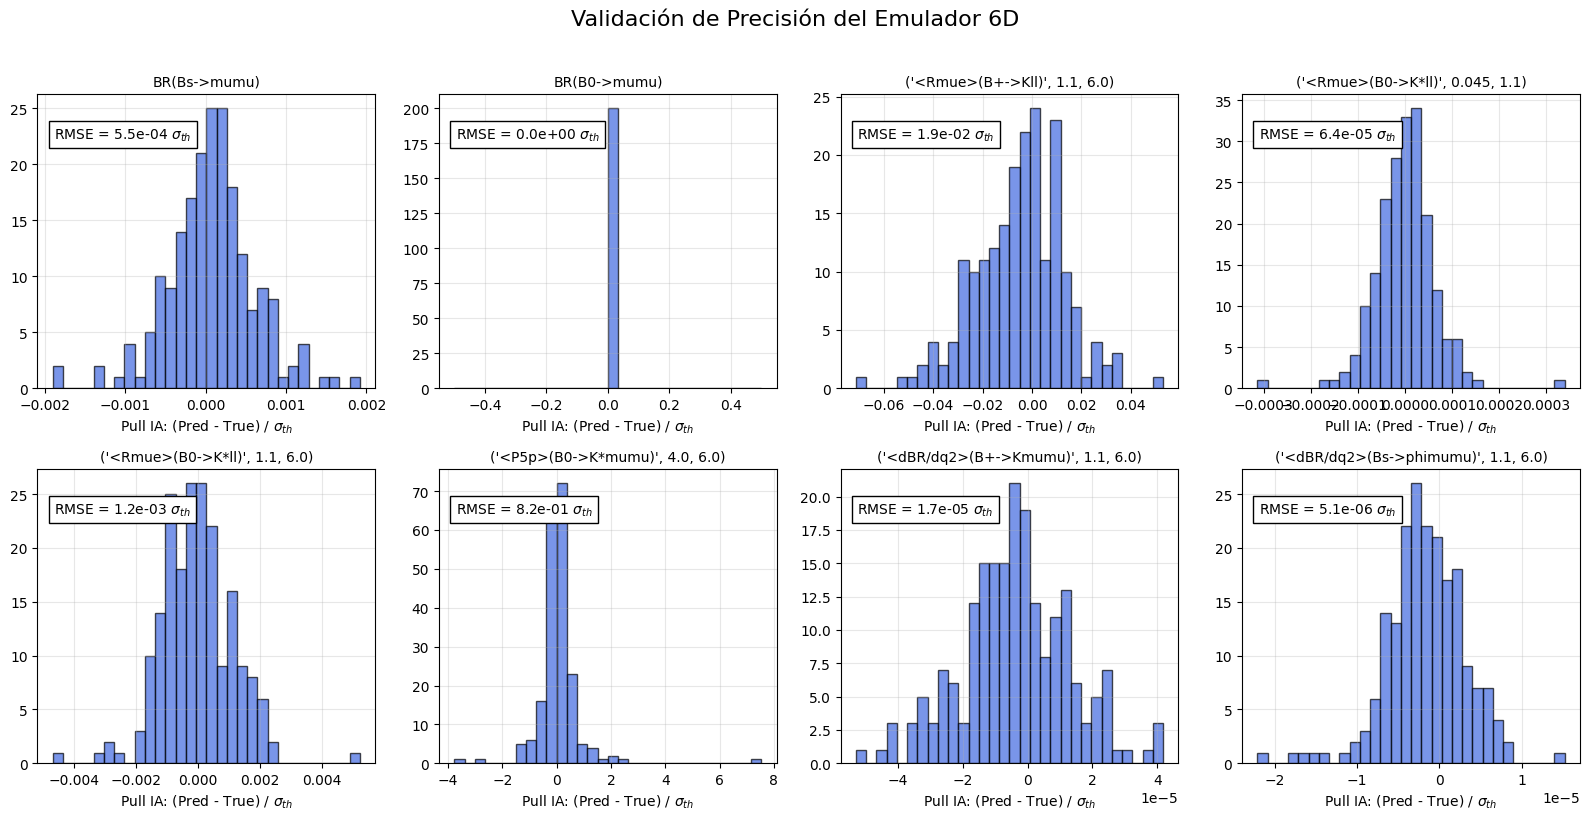


[+] Guardando modelo en disco...
 -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_c9p_c10p_cs_cp_6d.joblib'.


In [ ]:
import numpy as np
import pandas as pd
import warnings
import joblib
import matplotlib.pyplot as plt
from scipy.stats import qmc
import flavio
from wilson import Wilson
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 1 (6D): ENTRENAMIENTO DEL ORÁCULO IA (C9, C10, C9', C10', CS, CP) ")
print("="*85)

i_seed = 42
np.random.seed(i_seed)

observables = [
    'BR(Bs->mumu)', 'BR(B0->mumu)',  
    ('<Rmue>(B+->Kll)', 1.1, 6.0), ('<Rmue>(B0->K*ll)', 0.045, 1.1),      
    ('<Rmue>(B0->K*ll)', 1.1, 6.0), ('<P5p>(B0->K*mumu)', 4.0, 6.0),
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0), ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

# =====================================================================
# 1. COVARIANZA TEÓRICA
# =====================================================================
print(" Calculando Matriz de Covarianza Teórica del Modelo Estándar...")
cov_matrix_th_raw = flavio.sm_covariance(observables, N=2000, threads=1)
cov_matrix_th = cov_matrix_th_raw.loc[observables, observables].values if isinstance(cov_matrix_th_raw, pd.DataFrame) else cov_matrix_th_raw

# =====================================================================
# 2. ESPACIO DE ENTRENAMIENTO GLOBAL (6D)
# =====================================================================
# Orden: [C9, C10, C9p, C10p, CS, CP]
bounds_low = [-6.0,  1.0, -1.0, -1.0, -0.15, -0.15]  
bounds_high = [ 1.0, 10.0,  6.0,  4.0,  0.15,  0.15]   
N_train = 14000 
MAX_GP_POINTS = 7000

print(f"\n Generando {N_train} puntos teóricos con Flavio en 6D...")
print(f"    C9:  [{bounds_low[0]}, {bounds_high[0]}] | C10: [{bounds_low[1]}, {bounds_high[1]}] | C9': [{bounds_low[2]}, {bounds_high[2]}] | C10': [{bounds_low[3]}, {bounds_high[3]}] | CS: [{bounds_low[4]}, {bounds_high[4]}] | CP: [{bounds_low[5]}, {bounds_high[5]}]")
sampler = qmc.LatinHypercube(d=6, seed=i_seed)
X_raw = qmc.scale(sampler.random(n=N_train), bounds_low, bounds_high)

# Reducción por KMeans solo si se supera el umbral de 7000
if N_train > MAX_GP_POINTS:
    print(f" Reduciendo a {MAX_GP_POINTS} Inducing Points representativos con KMeans...")
    kmeans = KMeans(n_clusters=MAX_GP_POINTS, random_state=i_seed, n_init='auto').fit(X_raw)
    X_train = kmeans.cluster_centers_
else:
    X_train = X_raw

def get_flavio_preds(c9, c10, c9p, c10p, cs, cp):
    wc = Wilson({'C9_bsmumu': c9, 'C10_bsmumu': c10, 'C9p_bsmumu': c9p, 'C10p_bsmumu': c10p, 'CS_bsmumu': cs, 'CP_bsmumu': cp}, scale=5.0, eft='WET', basis='flavio')
    return [flavio.np_prediction(obs[0], wc, obs[1], obs[2]) if isinstance(obs, tuple) else flavio.np_prediction(obs, wc) for obs in observables]

Obs_train = np.array([get_flavio_preds(*x) for x in X_train])

# =====================================================================
# 3. ENTRENAMIENTO DE LOS PROCESOS GAUSSIANOS
# =====================================================================
print("\n Entrenando los Procesos Gaussianos en 6D...")
gps, scalers_y = {}, {}
scaler_x = StandardScaler().fit(X_train)
X_train_scaled = scaler_x.transform(X_train)

for i, col in enumerate(observables):
    col_name = str(col)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(Obs_train[:, i].reshape(-1, 1)).ravel()
    
    kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(6), length_scale_bounds=(1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=i_seed)
    gp.fit(X_train_scaled, y_scaled)
    
    gps[col_name] = gp
    scalers_y[col_name] = scaler_y

# =====================================================================
# 4. VALIDACIÓN DE PULLS (TEST SET INDEPENDIENTE)
# =====================================================================
N_val = 200
print(f"\n Generando Set de Validación ({N_val} puntos) para testear el GP 6D...")
X_val = qmc.scale(sampler.random(n=N_val), bounds_low, bounds_high)
Obs_val = np.array([get_flavio_preds(*x) for x in X_val])

X_val_scaled = scaler_x.transform(X_val)
preds_val = []
for i, col in enumerate(observables):
    col_name = str(col)
    m_scaled = gps[col_name].predict(X_val_scaled)
    m_real = scalers_y[col_name].inverse_transform(m_scaled.reshape(-1, 1)).ravel()
    preds_val.append(m_real)
preds_val = np.column_stack(preds_val)

err_th_static = np.sqrt(np.diag(cov_matrix_th))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(observables):
    ax = axes[i]
    residual_pull = (preds_val[:, i] - Obs_val[:, i]) / err_th_static[i]
    ax.hist(residual_pull, bins=30, color='royalblue', alpha=0.7, edgecolor='black')
    ax.set_title(str(col), fontsize=10)
    ax.set_xlabel(r"Pull IA: (Pred - True) / $\sigma_{th}$")
    ax.grid(alpha=0.3)
    rmse_pull = np.sqrt(np.mean(residual_pull**2))
    ax.text(0.05, 0.85, f"RMSE = {rmse_pull:.1e} $\sigma_{{th}}$", transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white'))

plt.suptitle("Validación de Precisión del Emulador 6D", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GUARDAR EL MODELO
# =====================================================================
print("\n Guardando modelo en disco...")
paquete_exportacion = {
    'observables': observables, 'gps': gps, 'scalers_y': scalers_y, 'scaler_x': scaler_x,
    'bounds_low': bounds_low, 'bounds_high': bounds_high, 'cov_matrix_th': cov_matrix_th
}
joblib.dump(paquete_exportacion, 'emulador_c9_c10_c9p_c10p_cs_cp_6d.joblib')
print(" -> ¡ÉXITO! Modelo guardado como 'emulador_c9_c10_c9p_c10p_cs_cp_6d.joblib'.")
print("="*85)

 SCRIPT 2 (6D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD 
 Emulador IA 6D cargado correctamente.

 Buscando el Mínimo Global en 6D (Algoritmo Genético)...

 Perfilando errores asimétricos...

 Calculando Matriz de Covarianza Analítica (Hessiano Multiescala)...

 Desglose de Incertidumbres en el Mínimo Global:
-------------------------------------------------------------------------------------
 OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) 
-------------------------------------------------------------------------------------
 BR(Bs->mumu)                   |       11.68 |            2.75 |           0.0018 
 BR(B0->mumu)                   |       70.14 |            4.98 |           0.0000 
 ('<Rmue>(B+->Kll)', 1.1, 6.0)  |        5.00 |            0.01 |           0.0003 
 ('<Rmue>(B0->K*ll)', 0.045, 1. |       10.76 |            0.47 |           0.0000 
 ('<Rmue>(B0->K*ll)', 1.1, 6.0) |        7.49 |            0.06 |           0.0001 
 ('<P5p>

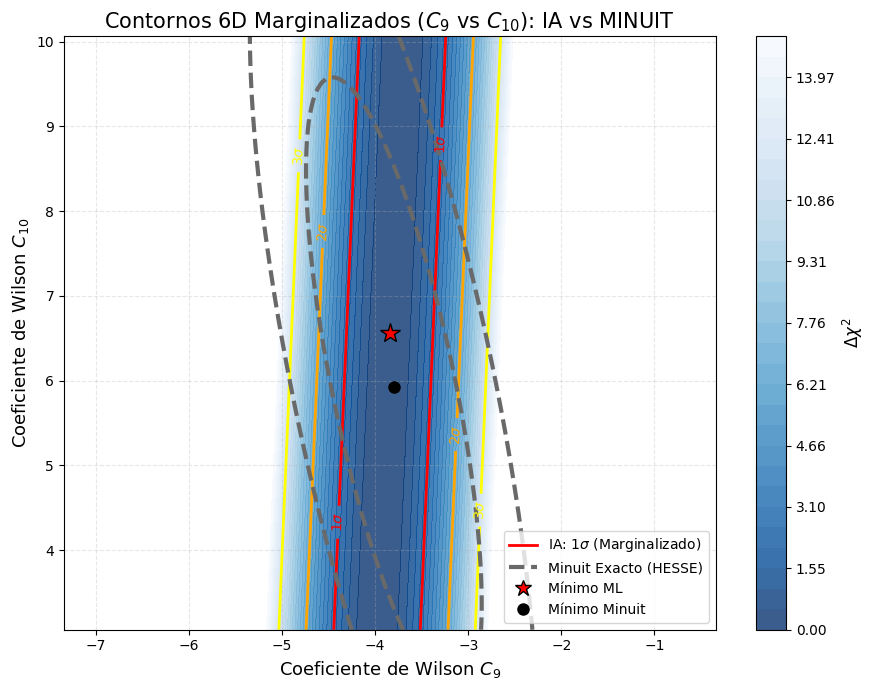


 Generando Gráfica 2: Desglose de Observables (Corte 1D en el Mínimo 6D)...


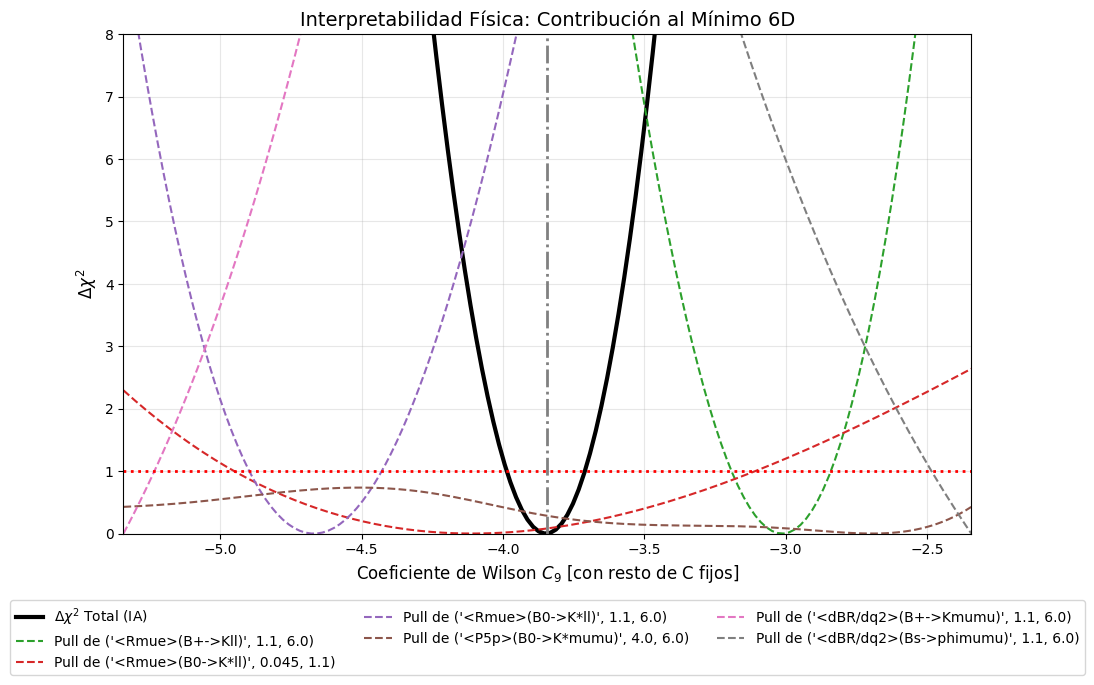


[Tabla de Impacto: Feature Importance Físico (6D)]
                          Observable  Mejora $\Delta\chi^2$  Importancia Relativa (%)
  ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0)                  61.62                     67.21
('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)                  30.07                     32.79
                        BR(Bs->mumu)                   0.00                      0.00
                        BR(B0->mumu)                   0.00                      0.00
    ('<Rmue>(B0->K*ll)', 0.045, 1.1)                   0.00                      0.00
       ('<Rmue>(B+->Kll)', 1.1, 6.0)                   0.00                      0.00
     ('<P5p>(B0->K*mumu)', 4.0, 6.0)                   0.00                      0.00
      ('<Rmue>(B0->K*ll)', 1.1, 6.0)                   0.00                      0.00

 Generando Gráfica 3: Corner Plot Analítico...


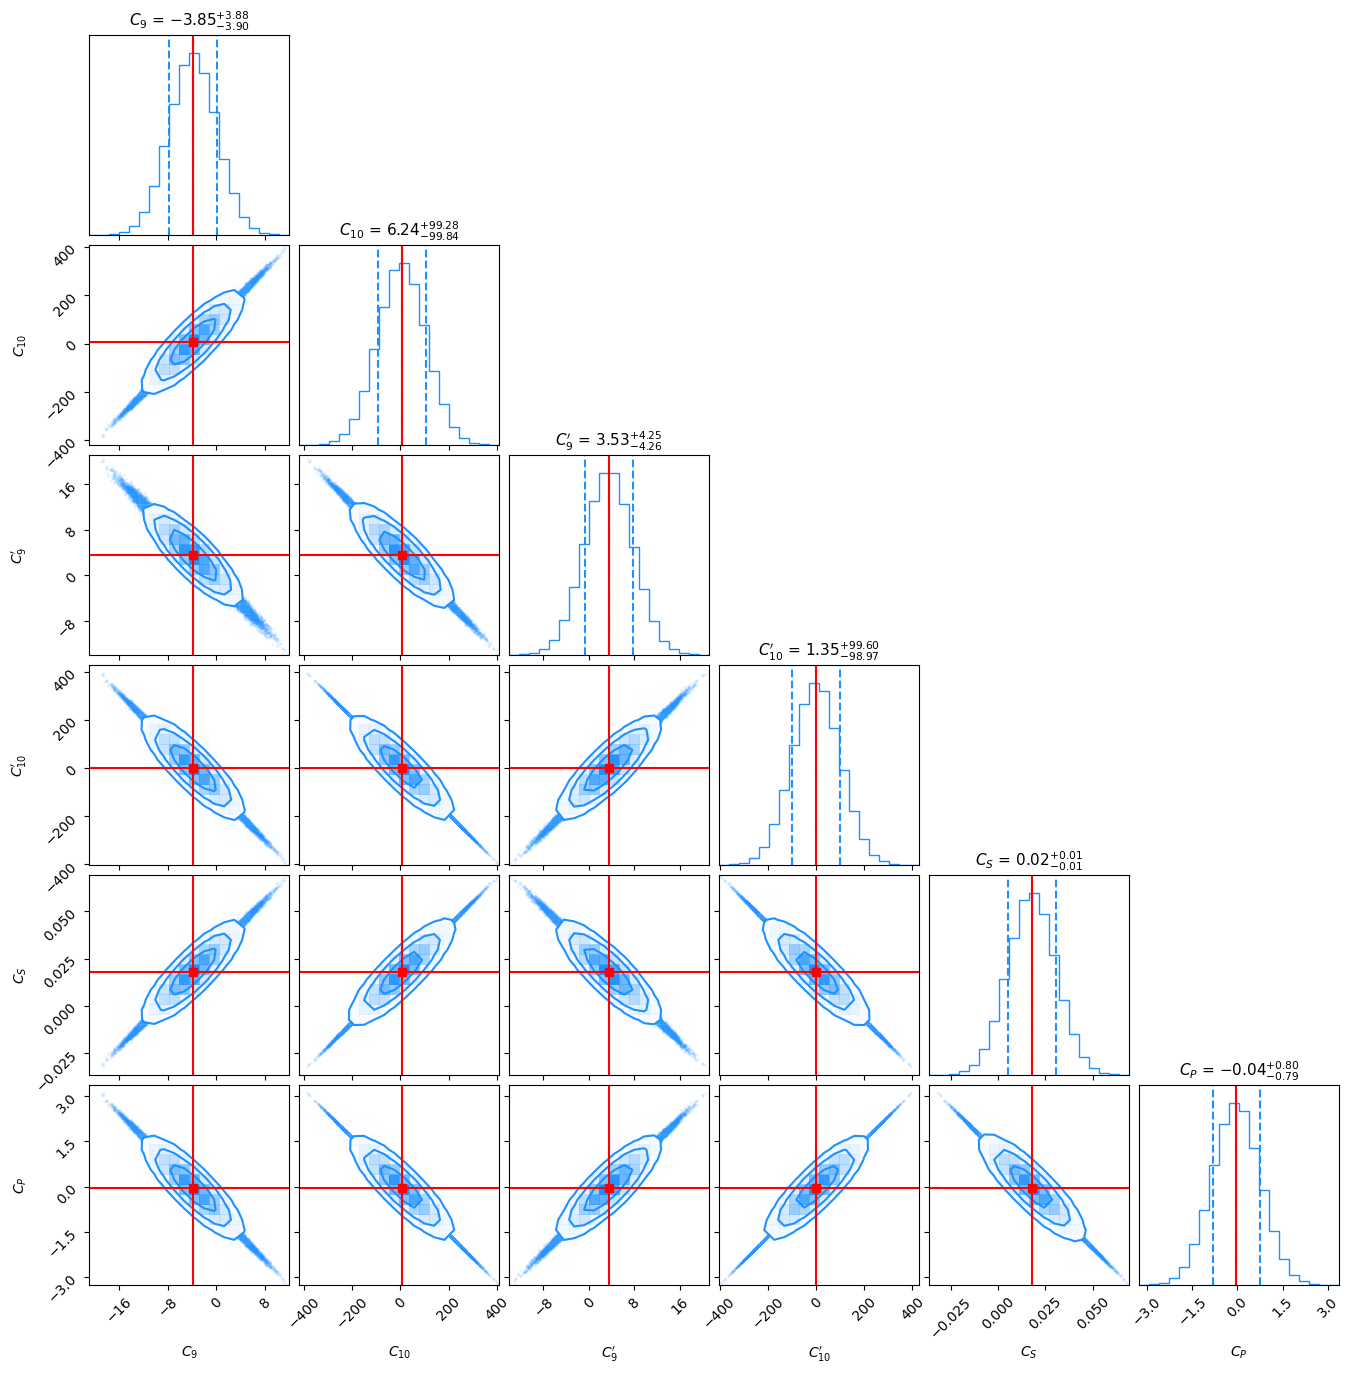


 BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO
[*] Generando 200 puntos aleatorios en 6D para el benchmark...
[*] Midiendo tiempo para 200 evaluaciones exactas con Flavio...
[*] Midiendo tiempo para 200 evaluaciones con el Emulador GP en Batch...

------------------------------------------------------------
                  RESULTADOS DEL BENCHMARK                  
------------------------------------------------------------
RENDIMIENTO COMPUTACIONAL:
   Tiempo Flavio (200 pts): 329.84 s (1649.18 ms / punto)
   Tiempo ML GP  (200 pts): 2.5444 s (12.7221 ms / punto)
   -> Speedup: ¡El Emulador IA es 130 veces más rápido!

------------------------------------------------------------



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import numdifftools as nd
from scipy.interpolate import interp1d
from scipy.optimize import minimize, root_scalar, differential_evolution
from scipy.linalg import cholesky, solve_triangular
from sklearn.preprocessing import StandardScaler
import corner 

warnings.filterwarnings('ignore')

print("="*85)
print(" SCRIPT 2 (6D): INFERENCIA GLOBAL RÁPIDA Y PROFILE LIKELIHOOD ")
print("="*85)

# =====================================================================
# 0. VALORES TARGET DE MINUIT (MODIFICAR AQUÍ)
# =====================================================================
T_C9_BEST, T_C9_UP, T_C9_DOWN = -3.7991, 0.8431, 0.4016
T_C10_BEST, T_C10_UP, T_C10_DOWN = 5.9234, 2.4722, 2.3497
T_C9P_BEST, T_C9P_UP, T_C9P_DOWN = 3.7973, 0.4140, 2.5911
T_C10P_BEST, T_C10P_UP, T_C10P_DOWN = 1.3153, 0.9394, 0.8672
T_CS_BEST, T_CS_UP, T_CS_DOWN = -0.0258, 0.0367, 0.0115
T_CP_BEST, T_CP_UP, T_CP_DOWN = -0.0260, 0.0841, 0.0351

T_R_C9_C10 = -0.70; T_R_C9_C9P =  0.80; T_R_C9_C10P =  0.20; T_R_C9_CS =  0.10; T_R_C9_CP =  0.10
T_R_C10_C9P= -0.90; T_R_C10_C10P= -0.80; T_R_C10_CS= -0.30; T_R_C10_CP= -0.20
T_R_C9P_C10P= 0.60; T_R_C9P_CS =  0.20; T_R_C9P_CP =  0.20
T_R_C10P_CS=  0.30; T_R_C10P_CP=  0.20
T_R_CS_CP  = -0.90

T_C9_ERR = (T_C9_UP + T_C9_DOWN) / 2.0
T_C10_ERR = (T_C10_UP + T_C10_DOWN) / 2.0
T_C9P_ERR = (T_C9P_UP + T_C9P_DOWN) / 2.0
T_C10P_ERR = (T_C10P_UP + T_C10P_DOWN) / 2.0
T_CS_ERR = (T_CS_UP + T_CS_DOWN) / 2.0
T_CP_ERR = (T_CP_UP + T_CP_DOWN) / 2.0

# =====================================================================
# 1. CARGA DEL MODELO IA
# =====================================================================
try:
    paquete = joblib.load('../Modelos_IA/emulador_c9_c10_c9p_c10p_cs_cp_6d.joblib')
    print(" Emulador IA 6D cargado correctamente.")
except FileNotFoundError:
    raise FileNotFoundError("Error: No se encontró el modelo.")

observables, gps = paquete['observables'], paquete['gps']
scalers_y, scaler_x = paquete['scalers_y'], paquete['scaler_x']
bounds_low, bounds_high = paquete['bounds_low'], paquete['bounds_high']
cov_matrix_th = paquete['cov_matrix_th']

def predict_fine(params):
    c_scaled = scaler_x.transform([params])
    means, stds = [], []
    for col in observables:
        m, s = gps[str(col)].predict(c_scaled, return_std=True)
        means.append(scalers_y[str(col)].inverse_transform(m.reshape(-1, 1))[0, 0])
        stds.append(s[0] * scalers_y[str(col)].scale_[0])
    return np.array(means), np.array(stds)

# =====================================================================
# 2. DATOS EXPERIMENTALES (LHCb)
# =====================================================================
datos_reales = {
    'BR(Bs->mumu)': {'c': 3.83e-9, 'e': np.sqrt(0.38**2 + 0.19**2 + 0.14**2) * 1e-9},
    'BR(B0->mumu)': {'c': 1.20e-10, 'e': np.sqrt(0.83**2 + 0.14**2) * 1e-10},
    ('<Rmue>(B+->Kll)', 1.1, 6.0): {'c': 0.949, 'e': np.sqrt(0.042**2 + 0.022**2)},
    ('<Rmue>(B0->K*ll)', 0.045, 1.1): {'c': 0.927, 'e': np.sqrt(0.093**2 + 0.036**2)},
    ('<Rmue>(B0->K*ll)', 1.1, 6.0): {'c': 1.027, 'e': np.sqrt(0.072**2 + 0.027**2)},
    ('<P5p>(B0->K*mumu)', 4.0, 6.0): {'c': -0.439, 'e': np.sqrt(0.111**2 + 0.036**2)},
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0): {'c': 1.19e-8, 'e': np.sqrt(0.03**2 + 0.06**2) * 1e-8},
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0): {'c': (2.88 / 4.9) * 1e-8, 'e': (np.sqrt(0.15**2 + 0.05**2 + 0.14**2) / 4.9) * 1e-8}
}

mean_vec = np.array([datos_reales[col]['c'] for col in observables])
err_vec = np.array([datos_reales[col]['e'] for col in observables])
cov_matrix_exp = np.diag(err_vec**2)
cov_matrix_exp[0, 1] = cov_matrix_exp[1, 0] = -0.11 * err_vec[0] * err_vec[1]
cov_matrix_exp[2, 4] = cov_matrix_exp[4, 2] = 0.03 * err_vec[2] * err_vec[4]
cov_matrix_exp[3, 4] = cov_matrix_exp[4, 3] = 0.05 * err_vec[3] * err_vec[4]
cov_matrix_base = cov_matrix_exp + cov_matrix_th

# =====================================================================
# 3. MINIMIZACIÓN GLOBAL DEL CHI^2
# =====================================================================
print("\n Buscando el Mínimo Global en 6D (Algoritmo Genético)...")
def chi2_fine(params):
    pred_mean, pred_std = predict_fine(params)
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    return np.sum(np.dot(L_inv, (mean_vec - pred_mean) / err_tot)**2)

bnds = list(zip(bounds_low, bounds_high))
res_global = differential_evolution(chi2_fine, bounds=bnds, strategy='best1bin', popsize=15, tol=0.01, seed=42)
res_real = minimize(chi2_fine, x0=res_global.x, bounds=bnds, method='L-BFGS-B')
bf_c9, bf_c10, bf_c9p, bf_c10p, bf_cs, bf_cp = res_real.x
chi2_min = res_real.fun

# =====================================================================
# 4. PROFILE LIKELIHOOD (INICIALIZACIÓN ITERATIVA BIDIRECCIONAL)
# =====================================================================
print("\n Perfilando errores asimétricos...")
def profile_1d(target_idx, grid_vals, best_fits):
    profile = np.zeros(len(grid_vals))
    min_idx = np.argmin(np.abs(grid_vals - best_fits[target_idx]))
    
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx, len(grid_vals)):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x 
        
    x0_nuisance = np.delete(best_fits, target_idx)
    for k in range(min_idx-1, -1, -1):
        def obj(nuisance):
            p = np.insert(nuisance, target_idx, grid_vals[k])
            return chi2_fine(p)
        bnds_nuisance = np.delete(bnds, target_idx, axis=0)
        res = minimize(obj, x0=x0_nuisance, bounds=bnds_nuisance, method='L-BFGS-B')
        profile[k] = res.fun
        x0_nuisance = res.x 
        
    return profile - chi2_min

def extract_roots(prof, grid, best_fit):
    f_interp = interp1d(grid, prof - 1.0, kind='cubic')
    try: err_down = best_fit - root_scalar(f_interp, bracket=[grid[0], best_fit]).root
    except ValueError: err_down = np.nan
    try: err_up = root_scalar(f_interp, bracket=[best_fit, grid[-1]]).root - best_fit
    except ValueError: err_up = np.nan
    return err_down, err_up

# Mallas centradas en el mínimo encontrado
grid_c9 = np.linspace(bf_c9 - 1.5, bf_c9 + 1.5, 30)
err_c9_down, err_c9_up = extract_roots(profile_1d(0, grid_c9, res_real.x), grid_c9, bf_c9)

grid_c10 = np.linspace(bf_c10 - 2.5, bf_c10 + 2.5, 30)
err_c10_down, err_c10_up = extract_roots(profile_1d(1, grid_c10, res_real.x), grid_c10, bf_c10)

grid_c9p = np.linspace(bf_c9p - 2.0, bf_c9p + 2.0, 30)
err_c9p_down, err_c9p_up = extract_roots(profile_1d(2, grid_c9p, res_real.x), grid_c9p, bf_c9p)

grid_c10p = np.linspace(bf_c10p - 2.0, bf_c10p + 2.0, 30)
err_c10p_down, err_c10p_up = extract_roots(profile_1d(3, grid_c10p, res_real.x), grid_c10p, bf_c10p)

grid_cs = np.linspace(bf_cs - 0.08, bf_cs + 0.08, 30)
err_cs_down, err_cs_up = extract_roots(profile_1d(4, grid_cs, res_real.x), grid_cs, bf_cs)

grid_cp = np.linspace(bf_cp - 0.08, bf_cp + 0.08, 30)
err_cp_down, err_cp_up = extract_roots(profile_1d(5, grid_cp, res_real.x), grid_cp, bf_cp)

# =====================================================================
# 5. CÁLCULO DE CORRELACIONES (HESSIANO MACROSCÓPICO MULTIESCALA)
# =====================================================================
print("\n Calculando Matriz de Covarianza Analítica (Hessiano Multiescala)...")
def num_hessian(func, x0): 
    n = len(x0)
    H = np.zeros((n, n))
    # Usamos eps grande para C9,C10 y eps pequeño para CS,CP para no salirnos de los bounds
    eps_vec = np.array([0.18, 0.18, 0.18, 0.18, 0.18, 0.18])
    for i in range(n):
        for j in range(n):
            if i <= j:
                x_pp, x_mm, x_pm, x_mp = x0.copy(), x0.copy(), x0.copy(), x0.copy()
                x_pp[i] += eps_vec[i]; x_pp[j] += eps_vec[j]
                x_mm[i] -= eps_vec[i]; x_mm[j] -= eps_vec[j]
                x_pm[i] += eps_vec[i]; x_pm[j] -= eps_vec[j]
                x_mp[i] -= eps_vec[i]; x_mp[j] += eps_vec[j]
                H[i,j] = (func(x_pp) - func(x_pm) - func(x_mp) + func(x_mm)) / (4 * eps_vec[i] * eps_vec[j])
                H[j,i] = H[i,j]
    return H

H_matrix = num_hessian(chi2_fine, np.array([bf_c9, bf_c10, bf_c9p, bf_c10p, bf_cs, bf_cp]))
eigvals, eigvecs = np.linalg.eigh(H_matrix)
eigvals = np.maximum(eigvals, 1e-4) 
H_matrix_pos = eigvecs @ np.diag(eigvals) @ np.linalg.inv(eigvecs)

cov_6d = np.linalg.inv(0.5 * H_matrix_pos)

def get_corr(i, j):
    corr = cov_6d[i, j] / np.sqrt(cov_6d[i,i] * cov_6d[j,j])
    return np.clip(corr, -1.0, 1.0) 

# =====================================================================
# 6. DESGLOSE DE INCERTIDUMBRES
# =====================================================================
print("\n Desglose de Incertidumbres en el Mínimo Global:")
print("-" * 85)
print(" OBSERVABLE                     | ERR EXP (%) | ERR TEÓRICO (%) | ERR EMULADOR (%) ")
print("-" * 85)
pred_bf_mean, pred_bf_std = predict_fine(res_real.x)
err_exp_abs = np.sqrt(np.diag(cov_matrix_exp))
err_th_abs  = np.sqrt(np.diag(cov_matrix_th))
for i, col in enumerate(observables):
    val = abs(mean_vec[i])
    pe = (err_exp_abs[i] / val) * 100
    pt = (err_th_abs[i] / val) * 100
    # Tope Inteligente de Varianza
    if scalers_y[str(col)].var_[0] < 1e-15:
        pi = 0.0000
    else:
        pi = (pred_bf_std[i] / val) * 100
    print(f" {str(col)[:30]:<30} | {pe:11.2f} | {pt:15.2f} | {pi:16.4f} ")
print("-" * 85)

# =====================================================================
# 7. TABLA FINAL COMPARATIVA
# =====================================================================
print("\n" + "="*115)
print(" RESULTADOS FINALES 6D: COMPARATIVA EMULADOR ML vs FLAVIO MINUIT ")
print("="*115)
print(" PARÁMETRO |    PREDICCIÓN EMULADOR GP          |    OBJETIVO FLAVIO MINUIT       | PULL ")
print("-" * 115)
print(f"    C9     | {bf_c9:+.4f} +{err_c9_up:.4f} -{err_c9_down:.4f}     | {T_C9_BEST:+.4f} +{T_C9_UP:.4f} -{T_C9_DOWN:.4f}     | {(bf_c9 - T_C9_BEST) / T_C9_ERR:+.2f} σ")
print(f"    C10    | {bf_c10:+.4f} +{err_c10_up:.4f} -{err_c10_down:.4f}     | {T_C10_BEST:+.4f} +{T_C10_UP:.4f} -{T_C10_DOWN:.4f}     | {(bf_c10 - T_C10_BEST) / T_C10_ERR:+.2f} σ")
print(f"    C9'    | {bf_c9p:+.4f} +{err_c9p_up:.4f} -{err_c9p_down:.4f}     | {T_C9P_BEST:+.4f} +{T_C9P_UP:.4f} -{T_C9P_DOWN:.4f}     | {(bf_c9p - T_C9P_BEST) / T_C9P_ERR:+.2f} σ")
print(f"    C10'   | {bf_c10p:+.4f} +{err_c10p_up:.4f} -{err_c10p_down:.4f}     | {T_C10P_BEST:+.4f} +{T_C10P_UP:.4f} -{T_C10P_DOWN:.4f}     | {(bf_c10p - T_C10P_BEST) / T_C10P_ERR:+.2f} σ")
print(f"    CS     | {bf_cs:+.4f} +{err_cs_up:.4f} -{err_cs_down:.4f}     | {T_CS_BEST:+.4f} +{T_CS_UP:.4f} -{T_CS_DOWN:.4f}     | {(bf_cs - T_CS_BEST) / T_CS_ERR:+.2f} σ")
print(f"    CP     | {bf_cp:+.4f} +{err_cp_up:.4f} -{err_cp_down:.4f}     | {T_CP_BEST:+.4f} +{T_CP_UP:.4f} -{T_CP_DOWN:.4f}     | {(bf_cp - T_CP_BEST) / T_CP_ERR:+.2f} σ")
print("="*115)
print(" MATRIZ CORRELACIÓN COMPLETA      |  EMULADOR GP  |  MINUIT FLAVIO  |  DIFERENCIA (Δ) ")
print("-" * 115)
corrs = [
    (0, 1, T_R_C9_C10,   "C9   - C10 "),
    (0, 2, T_R_C9_C9P,   "C9   - C9' "),
    (0, 3, T_R_C9_C10P,  "C9   - C10'"),
    (0, 4, T_R_C9_CS,    "C9   - CS  "),
    (0, 5, T_R_C9_CP,    "C9   - CP  "),
    (1, 2, T_R_C10_C9P,  "C10  - C9' "),
    (1, 3, T_R_C10_C10P, "C10  - C10'"),
    (1, 4, T_R_C10_CS,   "C10  - CS  "),
    (1, 5, T_R_C10_CP,   "C10  - CP  "),
    (2, 3, T_R_C9P_C10P, "C9'  - C10'"),
    (2, 4, T_R_C9P_CS,   "C9'  - CS  "),
    (2, 5, T_R_C9P_CP,   "C9'  - CP  "),
    (3, 4, T_R_C10P_CS,  "C10' - CS  "),
    (3, 5, T_R_C10P_CP,  "C10' - CP  "),
    (4, 5, T_R_CS_CP,    "CS   - CP  ")
]
for i1, i2, target, name in corrs:
    pred = get_corr(i1, i2)
    diff = pred - target
    print(f"    {name}                |     {pred:+.2f}     |      {target:+.2f}      |      {diff:+.2f}")

print("="*115)

# =====================================================================
# 8. GRÁFICA 1: COMPARATIVA ANALÍTICA (C9 vs C10 Marginalizado)
# =====================================================================
print("\n Generando Gráfica 1: Espacio de Parámetros Analítico (IA vs Minuit)...")
cov_2d_marginalizada = cov_6d[0:2, 0:2]
inv_cov_2d = np.linalg.inv(cov_2d_marginalizada)

cov_2d_minuit = np.array([[T_C9_ERR**2, T_R_C9_C10 * T_C9_ERR * T_C10_ERR], [T_R_C9_C10 * T_C9_ERR * T_C10_ERR, T_C10_ERR**2]])
inv_cov_2d_minuit = np.linalg.inv(cov_2d_minuit)

grid_res = 150
c9_mesh_grid = np.linspace(bf_c9 - 3.5, bf_c9 + 3.5, grid_res)
c10_mesh_grid = np.linspace(bf_c10 - 3.5, bf_c10 + 3.5, grid_res)
C9_mesh, C10_mesh = np.meshgrid(c9_mesh_grid, c10_mesh_grid)

Z_delta_chi2_IA = np.zeros(C9_mesh.shape)
Z_delta_chi2_Minuit = np.zeros(C9_mesh.shape)

for i in range(grid_res):
    for j in range(grid_res):
        d_ia = np.array([C9_mesh[i, j] - bf_c9, C10_mesh[i, j] - bf_c10])
        Z_delta_chi2_IA[i, j] = np.dot(d_ia.T, np.dot(inv_cov_2d, d_ia))
        
        d_m = np.array([C9_mesh[i, j] - T_C9_BEST, C10_mesh[i, j] - T_C10_BEST])
        Z_delta_chi2_Minuit[i, j] = np.dot(d_m.T, np.dot(inv_cov_2d_minuit, d_m))

plt.figure(figsize=(9, 7))
cs_fill = plt.contourf(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=np.linspace(0, 15, 30), cmap='Blues_r', alpha=0.8)
plt.colorbar(cs_fill).set_label(r'$\Delta\chi^2$', fontsize=12)
cs_lines_ia = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_IA, levels=[2.30, 6.18, 11.83], colors=['red', 'orange', 'yellow'], linewidths=2)
plt.clabel(cs_lines_ia, cs_lines_ia.levels, inline=True, fmt={2.30: r'1$\sigma$', 6.18: r'2$\sigma$', 11.83: r'3$\sigma$'}, fontsize=10)
cs_lines_minuit = plt.contour(C9_mesh, C10_mesh, Z_delta_chi2_Minuit, levels=[2.30, 6.18], colors='dimgray', linestyles='dashed', linewidths=3)

plt.plot(bf_c9, bf_c10, 'r*', markersize=15, markeredgecolor='black', label='Mínimo ML')
plt.plot(T_C9_BEST, T_C10_BEST, 'ko', markersize=8, label='Mínimo Minuit')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'IA: $1\sigma$ (Marginalizado)'),
    Line2D([0], [0], color='dimgray', lw=3, linestyle='dashed', label='Minuit Exacto (HESSE)'),
    Line2D([0], [0], marker='*', color='r', markeredgecolor='k', markersize=12, linestyle='None', label='Mínimo ML'),
    Line2D([0], [0], marker='o', color='k', markersize=8, linestyle='None', label='Mínimo Minuit')
]
plt.xlabel(r'Coeficiente de Wilson $C_9$', fontsize=13); plt.ylabel(r'Coeficiente de Wilson $C_{10}$', fontsize=13)
plt.title(r'Contornos 6D Marginalizados ($C_9$ vs $C_{10}$): IA vs MINUIT', fontsize=15)
plt.legend(handles=legend_elements, loc='lower right'); plt.grid(alpha=0.3, linestyle='--'); plt.tight_layout()
plt.show()

# =====================================================================
# 9. GRÁFICA 2: INTERPRETABILIDAD FÍSICA (DESGLOSE DE OBSERVABLES)
# =====================================================================
print("\n Generando Gráfica 2: Desglose de Observables (Corte 1D en el Mínimo 6D)...")
c9_slice = np.linspace(bf_c9 - 1.5, bf_c9 + 1.5, 150)
chi2_tot_vals = []
chi2_individuales = {col: [] for col in observables}

for c9_val in c9_slice:
    pred_mean, pred_std = predict_fine([c9_val, bf_c10, bf_c9p, bf_c10p, bf_cs, bf_cp])
    cov_tot = cov_matrix_base + np.diag(pred_std**2)
    err_tot = np.sqrt(np.diag(cov_tot))
    L_inv = solve_triangular(cholesky(cov_tot / np.outer(err_tot, err_tot), lower=True), np.eye(len(observables)), lower=True)
    delta_decorr = np.dot(L_inv, (mean_vec - pred_mean) / err_tot)
    chi2_tot_vals.append(np.sum(delta_decorr**2))
    delta = mean_vec - pred_mean
    for i, col in enumerate(observables):
        chi2_individuales[col].append((delta[i]**2) / cov_tot[i, i])

chi2_tot_vals = np.array(chi2_tot_vals) - chi2_min

plt.figure(figsize=(11, 7))
plt.plot(c9_slice, chi2_tot_vals, 'k-', linewidth=3, label=r'$\Delta\chi^2$ Total (IA)')
colores = plt.cm.tab10.colors
for i, col in enumerate(observables):
    perfil_indiv = np.array(chi2_individuales[col])
    perfil_indiv -= np.min(perfil_indiv)
    if np.max(perfil_indiv) > 0.2:
        plt.plot(c9_slice, perfil_indiv, color=colores[i%10], linestyle='--', linewidth=1.5, label=f'Pull de {col}')

plt.axhline(1.0, color='red', linestyle=':', linewidth=2); plt.axvline(bf_c9, color='gray', linestyle='-.', linewidth=2)
plt.ylim(0, 8); plt.xlim(c9_slice[0], c9_slice[-1])
plt.xlabel(f'Coeficiente de Wilson $C_9$ [con resto de C fijos]', fontsize=12)
plt.ylabel(r'$\Delta\chi^2$', fontsize=12)
plt.title('Interpretabilidad Física: Contribución al Mínimo 6D', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# =====================================================================
# 10. TABLA DE FEATURE IMPORTANCE FENOMENOLÓGICA
# =====================================================================
pred_sm_mean, pred_sm_std = predict_fine([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
importancia_fisica = {}
for i, col in enumerate(observables):
    chi2_sm = ((mean_vec[i] - pred_sm_mean[i])**2) / (cov_matrix_base[i,i] + pred_sm_std[i]**2)
    chi2_bf = ((mean_vec[i] - pred_bf_mean[i])**2) / (cov_matrix_base[i,i] + pred_bf_std[i]**2)
    importancia_fisica[str(col)] = chi2_sm - chi2_bf

print("\n[Tabla de Impacto: Feature Importance Físico (6D)]")
df_imp = pd.DataFrame(list(importancia_fisica.items()), columns=['Observable', 'Mejora $\Delta\chi^2$'])
df_imp['Mejora $\Delta\chi^2$'] = df_imp['Mejora $\Delta\chi^2$'].clip(lower=0) 
df_imp['Importancia Relativa (%)'] = (df_imp['Mejora $\Delta\chi^2$'] / df_imp['Mejora $\Delta\chi^2$'].sum()) * 100
print(df_imp.sort_values(by='Importancia Relativa (%)', ascending=False).reset_index(drop=True).to_string(index=False, float_format="%.2f"))

# =====================================================================
# 11. GRÁFICA 3: CORNER PLOT MARGINALIZADO (TOPOLOGÍA MULTIDIMENSIONAL)
# =====================================================================
print("\n Generando Gráfica 3: Corner Plot Analítico...")

# Generamos 100,000 muestras aleatorias basadas en nuestro Hessiano exacto
# (H_matrix_pos se calculó en el Paso 5)
matriz_cov_final = np.linalg.inv(0.5 * H_matrix_pos)
muestras_mcmc = np.random.multivariate_normal(res_real.x, matriz_cov_final, size=100000)

# Etiquetas dinámicas según la dimensión
if len(res_real.x) == 4:
    etiquetas = [r"$C_9$", r"$C_{10}$", r"$C_9^\prime$", r"$C_{10}^\prime$"]
elif len(res_real.x) == 6:
    etiquetas = [r"$C_9$", r"$C_{10}$", r"$C_9^\prime$", r"$C_{10}^\prime$", r"$C_S$", r"$C_P$"]
else:
    etiquetas = [f"Param {i}" for i in range(len(res_real.x))]

fig_corner = corner.corner(
    muestras_mcmc, 
    labels=etiquetas, 
    truths=res_real.x, # Marca el Best Fit con líneas
    truth_color='red',
    quantiles=[0.16, 0.50, 0.84], # Muestra los límites de 1 sigma en los histogramas 1D
    show_titles=True, 
    title_kwargs={"fontsize": 11},
    smooth=1.0,
    color='dodgerblue'
)
#fig_corner.suptitle(f"Topología Global {len(res_real.x)}D de la Likelihood", fontsize=16, y=1.02)
plt.show()

# =====================================================================
# PASO 12: BENCHMARK COMPUTACIONAL: FLAVIO vs ML SUBROGADO
# =====================================================================

print("\n" + "="*85)
print(" BENCHMARK COMPUTACIONAL Y DE PRECISIÓN: FLAVIO vs ML SUBROGADO")
print("="*85)

# N_evaluaciones = 200 es suficiente para una media estable sin esperar horas.
N_evaluaciones = 200 
dim = len(bounds_low)

print(f"[*] Generando {N_evaluaciones} puntos aleatorios en {dim}D para el benchmark...")
test_params = []
for _ in range(N_evaluaciones):
    p = [np.random.uniform(bounds_low[d], bounds_high[d]) for d in range(dim)]
    test_params.append(p)

# Diccionario dinámico para mapear la dimensión a las claves de Wilson correctas
keys_wilson = {
    1: ['C9_bsmumu'],
    2: ['C9_bsmumu', 'C10_bsmumu'],
    4: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu'],
    6: ['C9_bsmumu', 'C10_bsmumu', 'C9p_bsmumu', 'C10p_bsmumu', 'CS_bsmumu', 'CP_bsmumu']
}[dim]

# ---------------------------------------------------------
# 1. TIEMPO DE FLAVIO (Teoría Exacta)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones exactas con Flavio...")
start_time_flavio = time.time()

for p in test_params:
    # Flavio tiene que instanciar la clase Wilson y calcular las integrales cada vez
    wc_dict = {k: v for k, v in zip(keys_wilson, p)}
    wc = Wilson(wc_dict, scale=5.0, eft='WET', basis='flavio')
    
    for obs in observables:
        if isinstance(obs, tuple):
            _ = flavio.np_prediction(obs[0], wc, obs[1], obs[2])
        else:
            _ = flavio.np_prediction(obs, wc)

end_time_flavio = time.time()
t_flavio_total = end_time_flavio - start_time_flavio

# ---------------------------------------------------------
# 2. TIEMPO DEL MODELO ML (Inferencia Subrogada - BATCH)
# ---------------------------------------------------------
print(f"[*] Midiendo tiempo para {N_evaluaciones} evaluaciones con el Emulador GP en Batch...")
start_time_ml = time.time()

# Pasamos todos los puntos de golpe en una matriz
test_params_arr = np.array(test_params)
X_test_scaled = scaler_x.transform(test_params_arr)

# El GP predice los 1000 puntos simultáneamente
for col in observables:
    _, _ = gps[str(col)].predict(X_test_scaled, return_std=True)

end_time_ml = time.time()
t_ml_total = end_time_ml - start_time_ml

# ---------------------------------------------------------
# RESULTADOS FINALES: VELOCIDAD Y ACELERACIÓN
# ---------------------------------------------------------
aceleracion = t_flavio_total / t_ml_total

print("\n" + "-"*60)
print(" RESULTADOS DEL BENCHMARK ".center(60, " "))
print("-"*60)

print("RENDIMIENTO COMPUTACIONAL:")
print(f"   Tiempo Flavio ({N_evaluaciones} pts): {t_flavio_total:.2f} s ({t_flavio_total/N_evaluaciones*1000:.2f} ms / punto)")
print(f"   Tiempo ML GP  ({N_evaluaciones} pts): {t_ml_total:.4f} s ({t_ml_total/N_evaluaciones*1000:.4f} ms / punto)")
print(f"   -> Speedup: ¡El Emulador IA es {aceleracion:,.0f} veces más rápido!\n")
print("-"*60 + "\n")